# **Modelado Predictivo de Denuncias por Cibercriminalidad en España (2022-2024)**

### **Resumen del Proyecto**
Este estudio desarrolla un modelo analítico para predecir la evolución de las denuncias por ciberdelito en España, integrando datos oficiales de criminalidad del [**SEC - Sistema Estadístico de Criminalidad**](https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/) (Ministerio del Interior) con variables demográficas del [**INE - Instituto Nacional de Estadística**](https://www.ine.es/).

A través de la normalización por tasas de población, el proyecto identifica patrones territoriales y tendencias de hechos (denuncias) para anticipar el impacto de la delincuencia digital en la sociedad española, transformando datos administrativos en inteligencia predictiva.

**Nota:** El SEC solo registra denuncias. Para 2025 se estima que el volumen real podría ser mucho mayor, por lo que el **modelo predice "delincuencia oficial"**, **no "delincuencia real"**.

# **Índice del Proyecto: Arquitectura de Notebooks**

**01_Análisis Exploratorio de Datos (EDA)**:
- Definición del problema, marco teórico y objetivos del modelo.
- Ingesta de fuentes crudas, tratamiento de nulos, normalización de provincias y validación técnica de tipos de datos.
- Visualización avanzada. Mapas de calor, tendencias temporales y distribución por tipologías.

**02_Modelado_Predictivo (Predictive Modeling)**:
- Entrenamiento de algoritmos,
- Evaluación de métricas y
- Proyecciones de denuncias por cibercriminalidad 2025.

# **1. Enmarcar el Problema (Business & Data Understanding)**

## **1.1 Objetivo del Estudio**
El objetivo central de esta investigación es transformar el histórico de denuncias por cibercriminalidad en España en un **modelo predictivo provincial**. El proyecto propone la transición de la **analítica descriptiva tradicional** hacia la **analítica predictiva**, permitiendo anticipar tendencias antes de que se consoliden.

* **El Problema:** El crecimiento exponencial de los ciberdelitos genera una saturación en los recursos de seguridad. Actualmente, la gestión es mayoritariamente reactiva, basada en informes consolidados a año vencido.
* **La Solución:** Un modelo de **Aprendizaje Supervisado (Supervised Learning)** enfocado en **Regresión de Series Temporales** que identifique provincias y perfiles de riesgo con mayor probabilidad de crecimiento.
* **Impacto Proactivo:** Proporcionar una herramienta de inteligencia capaz de estimar el volumen de infracciones para optimizar la asignación de recursos y el diseño de campañas de prevención dirigidas.

## **1.2 Evaluación del Rendimiento**
Para validar la utilidad operativa del modelo y asegurar que las predicciones sean accionables, se utilizarán las siguientes métricas de evaluación:

| Métrica | Definición | Relevancia en el Proyecto |
| :--- | :--- | :--- |
| **WAPE**<br>(Weighted Abs.<br>Pct. Error) | Error porcentual absoluto<br>ponderado por el volumen<br>total de los datos. | **Métrica Clave:** Evalúa la<br>precisión relativa global,<br>siendo más robusta que<br>el MAPE ante valores bajos. |
| **MAE**<br>(Mean Absolute<br>Error) | Promedio de las diferencias<br>absolutas entre la predicción<br>y la realidad física. | Cuantifica el error promedio<br>en unidades reales (denuncias);<br>permite entender la desviación<br>física en cada provincia. |
| **R² Score**<br>(Coef. de<br>Determinación) | Medida estadística de qué<br>tan cerca están los datos<br>de la línea de regresión. | Indica la capacidad del modelo<br>para explicar la variabilidad;<br>crítico para medir la<br>fiabilidad de la tendencia. |

---

**Tabla de Modelos Utilizados**

| Modelo | Tipo | Qué aporta al proyecto | Cuándo es útil |
| :--- | :--- | :--- | :--- |
| **Ridge Regression** | Lineal con<br>regularización L2 | Modelo simple,<br>estable e interpretable.<br>Sirve como referencia base<br>para entender relaciones<br>directas entre variables. | Cuando buscamos<br>interpretabilidad y comprobar<br>si la evolución del delito<br>sigue patrones lineales. |
| **Random Forest Regressor** | Ensamble de árboles<br>(no lineal) | Capta interacciones<br>complejas entre provincias,<br>tipologías y tasas.<br>Robusto ante ruido y<br>variabilidad territorial. | Cuando existen cambios<br>bruscos, comportamientos<br>heterogéneos o relaciones<br>no lineales. |
| **XGBoost Regressor** | Boosting de árboles | Muy potente para datos<br>estructurados. Aprende<br>patrones sutiles y<br>dependencias temporales. | Cuando pequeñas variaciones<br>anuales tienen impacto<br>acumulado y se requiere<br>máxima capacidad predictiva. |

---

> En este proyecto se **combinan modelos lineales y no lineales** para capturar tanto **relaciones simples** como **patrones complejos** en la evolución de los ciberdelitos. Esta diversidad metodológica permite seleccionar el enfoque más adecuado para cada tipología delictiva y evaluar la estabilidad del fenómeno a nivel provincial.

# **2. SEC – Estrategia de Datos y Metodológica (Data Strategy)**  

El proyecto se apoya en datos oficiales del [**Sistema Estadístico de Criminalidad (SEC)**](https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/) del Ministerio del Interior, garantizando trazabilidad, consistencia y validez estadística.

---

**2.1 Origen de los Datos**  
Los datos se obtienen del **Portal Estadístico de Criminalidad**, siguiendo la ruta: `Portal Estadístico de Criminalidad > Áreas Temáticas > Cibercriminalidad > Series anuales`

* **Fuente principal utilizada:** [Series Anuales de Cibercriminalidad - Ministerio del Interior](https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/datos.html?type=jaxi&title=Cibercriminalidad&path=/Datos5/)

* **Mi Target:** Registra la incidencia delictiva real (denuncias o actuaciones de oficio). Este archivo contiene el volumen de infracciones desglosadas por grupo penal, según la documentación del SEC, y por periodo anual, siendo la variable principal que mi modelo debe predecir.


* **Información Adicional:** Para profundizar en las definiciones legales o el sistema de recogida, se puede consultar el apartado oficial de [Metodología del SEC](https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/metodologia.html).

---

**2.2 Justificación Técnica del Marco de Datos**

- **Serie estable (2022–2024):** Se inicia en 2022, año en que la integración de Mossos y Ertzaintza y la reforma del Código Penal consolidan una serie homogénea y comparable.

- **Datos definitivos:** Se emplean únicamente cifras anuales consolidadas, evitando la volatilidad de los datos provisionales trimestrales.

- **Periodicidad anual:** El SEC publica los datos de cibercriminalidad exclusivamente con frecuencia **anual**, lo que genera series temporales cortas por provincia. Esta estructura define el enfoque metodológico del proyecto y orienta el análisis hacia modelos supervisados que integran información territorial y demográfica.

- **Sin ajustes previos:** El SEC no aplica correcciones estacionales. El modelo trabaja con datos brutos y detecta patrones mediante técnicas de Machine Learning.

- **Gobernanza y cumplimiento:** Datos anonimizados y sujetos al secreto estadístico, compatibles con análisis demográficos (RGPD).

---

**2.3 Tipologías de Cibercriminalidad (8 Agrupaciones Estratégicas)**  

Durante la fase de **EDA (Exploratory Data Analysis)**, se inspeccionará los hechos en base a la tipologías basada en los bloques definidos por el Ministerio del Interior.

> **Referencia Metodológica:** Tabla de tipologías (pág. 4) del documento [Metodología de Cibercriminalidad (SEC)](https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/dam/jcr:d96d4063-98d8-4647-8c76-d46a331a4ba3/03_Metodolog%C3%ADa_Cibercriminalidad.pdf).

---

**Tabla de Tipologías (SEC – 8 Agrupaciones Estratégicas)**

| Grupo penal | Delitos incluidos según SEC | Grupo penal | Delitos incluidos según SEC |
| --- | --- | --- | --- |
| **fraude_<br>informatico** | estafas con tarjetas de crédito,<br>débito y cheques de viaje<br>otras estafas<br>estafas informáticas<br>estafa de inversores<br>estafa bancaria | **interferencia_<br>en_los_datos_y_<br>en_el_sistema** | ataques a datos o<br>programas informáticos<br>ataques a sistemas<br>informáticos<br>ataques informáticos<br>daños |
| **amenazas_y_<br>coacciones** | amenazas<br>extorsión<br>coacciones<br>acoso contra la libertad<br>de las personas<br>acoso laboral o funcionarial<br>trato degradante<br>amenazas a grupo étnico,<br>cultural o religioso | **delitos_<br>sexuales** | sexting<br>delito de contacto mediante<br>tecnología con menor de 16 años<br>con fines sexuales (grooming)<br>pornografía de menores<br>agresión sexual<br>acoso sexual<br>abuso sexual<br>abuso sexual con penetración<br>agresión sexual con penetración<br>corrupción de menores/con<br>discapacidad/diversidad funcional<br>exhibicionismo<br>provocación sexual<br>delitos relativos a la<br>prostitución |
| **falsificacion_<br>informatica** | usurpación de estado civil<br>falsificación/tráfico de tarjetas<br>crédito y débito/cheques de viaje<br>otras falsificaciones de<br>documentos<br>fabricación/tenencia de útiles<br>para falsificar<br>falsificación de moneda, sellos<br>y efectos timbrados<br>falsificación/tráfico de<br>dni/pasaporte | **contra_el_<br>honor** | injurias<br>perfiles falsos con fines de<br>acoso/hostigamiento/humillación<br>calumnias<br>injurias y calumnias a<br>funcionario público, autoridad<br>o sus agentes<br>distribución/difusión pública<br>por nuevas tecnologías de la<br>promoción de delitos contra la<br>prostitución |
| **acceso_e_<br>interceptacion_<br>ilicita** | acceso ilegal a sistemas<br>informáticos<br>descubrimiento/revelación<br>de secretos<br>usurpación de funciones públicas<br>acceso ilegal informático<br>descubrimiento y revelación de<br>secretos e informaciones relativas<br>a la defensa nacional<br>facilitación de dispositivos,<br>programas o claves para acceder<br>ilegalmente a datos o sistemas<br>informáticos<br>facilitación de dispositivos,<br>programas o claves para cometer<br>ataques informáticos<br>interceptación de transmisiones<br>no públicas de datos informáticos<br>intrusismo | **contra_la_<br>propiedad_<br>industrial/<br>intelectual** | contra la propiedad industrial<br>contra la propiedad intelectual<br>acceso fraudulento a servicios de<br>radiodifusión/tv/otros<br>delito de espionaje industrial y<br>secreto profesional<br>otros relativos al<br>mercado/consumidores |

# **3. INE – Estrategia de Datos y Metodológica (Data Strategy)**

**Origen de los Datos y Consulta**

Los datos demográficos han sido extraídos del **INE – Instituto Nacional de Estadística**, siguiendo la ruta:

`INEbase > Demografía y población > Cifras de población y Censos demográficos > Estadística continua de población. Resultados`

* **Archivo seleccionado:**  
  *[Población residente por fecha, sexo y generación – edad a 31 de diciembre](https://www.ine.es/jaxiT3/Tabla.htm?t=56946#:~:text=Estad%C3%ADstica%20Continua%20de%20Poblaci%C3%B3n:%20Poblaci%C3%B3n%20residente%20por,(edad%20a%2031%20de%20diciembre).%20Trimestral.%20Provincias.)*

# **4. Análisis Exploratorio de Datos (EDA)**

**Métricas clave del SEC**

El SEC estructura la cibercriminalidad a partir de un conjunto de métricas que permiten **comparar territorios**, **detectar tendencias** y **describir la composición delictiva**.  

Estas métricas no son arbitrarias: están diseñadas para que los Analistas y Data Science puedan interpretar correctamente fenómenos que, por naturaleza, son **desiguales entre provincias**, **muy dinámicos** y **fuertemente dominados por el fraude informático**.

A continuación se describen las métricas que se incorporarán al dataset y que guiarán todo el análisis visual.

---

**1. Total de Hechos (volumen real de denuncias)**  
Es la unidad básica del SEC. Representa el número total de denuncias registradas en una provincia por año y tipología penal.

- **¿Por qué es importante?:** Porque permite medir el tamaño real del fenómeno.

---

**2. Tasa de Criminalidad por 1.000 habitantes (normalización territorial)**  
**¿Por qué se usa la Tasa y no el dato bruto?**

Para comparar regiones con poblaciones muy distintas (ej. Madrid vs. La Rioja), necesitamos "normalizar" los datos. La **Tasa de Criminalidad** nos permite ver cuántos delitos ocurren por cada 1.000 habitantes, **eliminando el sesgo del tamaño de la población**. Es decir, la tasa no es un conteo de personas, sino un **indicador de incidencia.**

$$\text{Tasa Criminalidad} = \frac{\text{Total Hechos}}{\text{Población}} \times 1.000$$

**Ejemplo explicativo:**
Si una provincia con **50.000 habitantes** registra **100 delitos**, su tasa sería de **2,00**.

*   **Cálculo:** $(100 / 50.000) \times 1.000 = 2$.

Si otra provincia con **1.000.000 de habitantes** registra **1.000 delitos**, su tasa sería de **1,00**.

Aunque la segunda tiene 10 veces más delitos brutos, la **Tasa** nos revela que la primera tiene el doble de incidencia criminal por habitante. Esto permite investigar si el modelo de Machine Learning debería comparar ambas regiones bajo un mismo estándar.

Al usar la base de 1.000 (habitual en seguridad ciudadana en España), las tasas suelen moverse en rangos de unidades de un solo dígito o decenas bajas.

---

**3. Distribución por tipología penal (composición delictiva) y Peso del fraude dentro del total ciber (dominancia del fraude)**

Tanto la **Distribución por tipología penal** como el **Peso del fraude dentro del total ciber** utilizan la misma fórmula, porque ambas miden **qué porcentaje del total de ciberdelitos de una provincia corresponde a una tipología concreta**. Lo que cambia es el foco analítico: una analiza todas las tipologías y la otra solo el fraude.

La fórmula general es:

$$\text{Peso} = \frac{\text{Hechos por grupo penal}}{\text{Total de hechos provinciales}} \times 100$$

La diferencia está en **qué se mide** y **para qué se usa**:

---

**3.1. Distribución por tipología penal (reparto completo)**  
Permite ver **cómo se reparte el delito** en una provincia:  
fraude, amenazas, falsificación, acceso ilícito, etc.

Sirve para responder:  
> “¿Cuál es el perfil delictivo completo de esta provincia?”

**Ejemplo Alicante 2024 — Distribución por Tipología Penal**

| Grupo penal               | Hechos | Fórmula aplicada                               | Resultado |
|---------------------------|--------|------------------------------------------------|-----------|
| fraude_informatico        | 4050   | (4050 / 4655) × 100                            | 87.0%     |
| amenazas_y_coacciones     | 120    | (120 / 4655) × 100                             | 2.58%     |
| falsificacion_informatica | 80     | (80 / 4655) × 100                              | 1.72%     |
| acceso_ilicito            | 405    | (405 / 4655) × 100                             | 8.70%     |
| **TOTAL provincial**      | **4655** | —                                              | —         |

**Interpretación:**  
Alicante tiene un perfil fuertemente dominado por fraude (87%).

---

**3.2. Peso del fraude dentro del total ciber (métrica específica)**  
Es un **caso particular** de la fórmula anterior, pero se trata como métrica independiente para medir únicamente el fraude informático.

Sirve para responder:  
> “¿Cuánto condiciona el fraude informático la estructura delictiva de esta provincia?”

**Ejemplo — Peso del fraude en Alicante 2024**

| Concepto                | Valor | Fórmula aplicada                     | Resultado |
|-------------------------|-------|--------------------------------------|-----------|
| Hechos de fraude        | 4050  | (4050 / 4655) × 100                  | 87.0%     |
| Total ciberdelitos      | 4655  | —                                    | —         |

**¿Por qué esta métrica es crítica para el modelo?**

1. **El fraude distorsiona todo el análisis:** Si no se controla su peso, el modelo puede aprender patrones falsos (por ejemplo, creer que todas las provincias se comportan igual).

2. **Ayuda a detectar provincias atípicas:** Algunas provincias tienen un fraude del 70%, otras del 95%. Esa diferencia es **información predictiva**.

3. **Es una feature de “estructura interna”:** No mide volumen ni crecimiento, sino **cómo se compone el delito** en cada territorio.

En resumen ambas métricas comparten la misma base matemática porque ambas expresan proporciones dentro del total provincial. Lo que cambia es el foco analítico: una analiza todas las tipologías y la otra solo el fraude informático.

---

**4. Variación interanual (VAR%)**

La Variación Interanual (VAR%) mide **cuánto ha crecido o disminuido un delito entre un año y el siguiente**.  
El SEC la utiliza para detectar **aceleraciones**, **descensos**, **saltos anómalos** y, en general, para analizar **dinámicas temporales**, no solo niveles absolutos.

Sirve para responder:

- ¿Este delito está acelerándose o estabilizándose?  
- ¿Ha habido un salto anómalo entre dos años?  
- ¿Qué provincias están creciendo más rápido?  

**¿Por qué es importante?**  
Porque mide la **dinámica temporal delictiva**, ayuda a identificar provincias “en crecimiento” o “en estabilización” y es una de las features más útiles para modelos predictivos.

La fórmula es: $$\text{VAR%} = \frac{H_t - H_{t-1}}{H_{t-1}} \times 100$$

---

**Ejemplo Alicante 2024 — Cálculo de VAR% para acceso ilícito**

Alicante registra:

- **318 hechos** en 2023  
- **405 hechos** en 2024  

Aplicamos la fórmula:

$$\text{VAR%} = \frac{405 - 318}{318} \times 100$$

**Tabla del cálculo**

| Año | Hechos | Fórmula aplicada                     | Resultado |
|-----|--------|--------------------------------------|-----------|
| 2023 | 318    | —                                    | —         |
| 2024 | 405    | (405 − 318) / 318 × 100              | 27.3%     |

**Interpretación:**  
Entre 2023 y 2024, el delito de acceso ilícito en Alicante **crece un 27.3%**, lo que indica una **aceleración significativa** del fenómeno en esta tipología penal.

---

**5. Ranking por intensidad (comparación entre provincias)**  
Al ordenar provincias por su tasa de Criminalidad permite identificar:

- focos de alta incidencia, territorios atípicos y patrones geográficos relevantes.

- **Por qué es importante:**  
  Resume la situación territorial de un vistazo.  
  Es una métrica muy utilizada en informes del SEC.

---

**4.2 Objetivos del EDA para el modelado**

Este análisis avanzado permitirá:

1. **Auditoría de fiabilidad de métricas**  
   Verificar que `Total_Hechos` y `Tasa_Criminalidad` presentan patrones coherentes, sin saltos administrativos ni anomalías que distorsionen el periodo 2022–2024.

2. **Validación de la ventana temporal**  
   Confirmar que el trienio 2022–2024 es estadísticamente estable y adecuado como base para la predicción de 2025.

3. **Análisis de densidad territorial**  
   Explorar diferencias entre provincias y CCAA mediante tasas por 1.000 habitantes para identificar focos de alta intensidad delictiva.

4. **Desglose por tipología penal**  
   Evaluar la dominancia del **fraude informático** y su peso relativo dentro del total de ciberdelitos, así como el comportamiento del resto de grupos penales.

5. **Consistencia territorial del panel**  
   Comprobar que las 52 provincias disponen de datos completos para 2022–2024, garantizando un panel equilibrado para el entrenamiento del modelo.

In [ ]:
#@title Ingesta y configuración del entorno
#En esta sección se prepara el entorno de trabajo mediante la importación de
#librerías y la configuración inicial necesaria para el análisis.

# Importar librerías necesarias

# El orden sigue una jerarquía de "de fuera hacia dentro":
# Sistema -> Análisis -> Visualización.

# --- Gestión de archivos, sistema y Google Drive ---
import os                        # Navegación por el sistema de archivos
import shutil                    # Automatización de copiado de archivos (Drive -> Colab)
import requests                  # Peticiones HTTP (descarga de archivos GeoJSON/datos desde URL)

# --- Manipulación y limpieza de datos ---
import pandas as pd              # Estructuras de datos y análisis estadístico
import numpy as np               # Operaciones matemáticas y matrices

# --- Normalización de texto ---
import unicodedata               # Manejo de caracteres Unicode (quitar tildes, acentos, normalizar texto)
# ¿Para qué sirve unicodedata?
# → Permite transformar caracteres acentuados (á, é, í, ó, ú, ñ) en su versión simple (a, e, i, o, u, n)
#   Esto es clave cuando queremos comparar textos sin que los acentos generen categorías distintas.
#   Ejemplo: "Ávila" y "Avila" pasan a ser equivalentes.
import re                         # Expresiones regulares (limpieza y corte de texto avanzado)
# ¿Para qué sirve re?
# → Permite buscar patrones complejos y "limpiar" el texto de forma quirúrgica.
#   En este proyecto es clave para cortar nombres de provincias (ej. Araba/Álava -> Araba)
#   y normalizar los grupos de edad (ej. "De 18 a 25 años" -> "18_25").

# --- Visualización de datos ---
import seaborn as sns             # Gráficos estadísticos estáticos (ideales para la memoria escrita)
import matplotlib.pyplot as plt   # Motor base de gráficos y personalización
import matplotlib.ticker as mtick  # Formateo de ejes (puntos de millar, porcentajes)
import plotly.express as px       # Visualizaciones interactivas y mapas rápidos (Choropleth)
import json                       # Manipulación de archivos GeoJSON (necesario para las coordenadas del mapa)
import plotly.graph_objects as go # Control total sobre figuras (capas, mapas complejos y botones)
from plotly.subplots import make_subplots
# ¿Para qué sirve make_subplots?
# → Es el "arquitecto" de las visualizaciones avanzadas.
#   Permite crear gráficos con doble eje Y (esencial para comparar Hechos vs Víctimas)
#   o cuadrículas de varios gráficos en una sola imagen, manteniendo escalas independientes.

# --- Framework de Machine Learning y Pipeline ---
from sklearn.base import BaseEstimator, TransformerMixin
# ¿Para qué sirve esto?
# → Permite crear "transformadores" personalizados que se integran con Scikit-Learn.
#   Es lo que usare para que la limpieza de provincias sea automática y reutilizable.

# --- Herramientas de Análisis Exploratorio Automático (EDA) ---
# Se dejan comentadas para activar según necesidad de profundidad
!pip install ydata-profiling
from ydata_profiling import ProfileReport

print("Entorno de trabajo listo. Librerías cargadas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.2 MB/s eta 0:00:00
Entorno de trabajo listo. Librerías cargadas correctamente.


/tmp/ipykernel_5709/773486038.py:53: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
# ==============================================================================
#@title Inspección inicial de archivos originales (SEC - Hechos e INE -Población)
#tras decargar los CSV del INE y SEC se procede a hacer una primera visualización
#de los datos par ver como están estructurados
# ==============================================================================

#Cargar datos
print("Iniciando carga de datos brutos SEC e INE")
df_hechos_raw = pd.read_csv('hechos_170426.csv', sep=';', dtype=str)
df_ine_raw = pd.read_csv('ine_170426.csv', sep=';', dtype=str)
print("Archivos cargados correctamente.\n")

# Estructura de control para inspeccionar ambos datasets
datasets_inspeccion = {
    "HECHOS (hechos_170426.csv)": df_hechos_raw,
    "INE (ine_170426.csv)": df_ine_raw
}

for nombre, df in datasets_inspeccion.items():
    print("="*60)
    print(f"DATOS ORIGINALES: {nombre}")
    print("="*60)
    display(df.head(5))

    print("\nEstructura de columnas y tipos detectados:")
    df.info()

    print(f"\nMuestra de valores en columna 'Total' de {nombre}:")
    print(df['Total'].unique()[:10])
    print("\n")

# Inspección de las dimensiones demográficas del INE
print("="*60)
print("AUDITORÍA DE COLUMNAS CRÍTICAS DEL INE")
print("="*60)
columnas_ine = ['Generación', 'Sexo', 'Provincias', 'Periodo']

for col in columnas_ine:
    valores_unicos = df_ine_raw[col].unique()
    print(f"\nColumna '{col}': {df_ine_raw[col].nunique()} categorías únicas.")
    print(f"Muestra (primeros 20): {valores_unicos[:20]}")

Iniciando carga de datos brutos SEC e INE
Archivos cargados correctamente.

DATOS ORIGINALES: HECHOS (hechos_170426.csv)


,Provincias,Grupo penal,periodo,Total
0,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2024,9.773
1,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2023,7.367
2,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2022,5.578
3,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2021,5.342
4,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2020,4.653



Estructura de columnas y tipos detectados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6930 entries, 0 to 6929
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Provincias   6930 non-null   object
 1   Grupo penal  6930 non-null   object
 2   periodo      6930 non-null   object
 3   Total        6930 non-null   object
dtypes: object(4)
memory usage: 216.7+ KB

Muestra de valores en columna 'Total' de HECHOS (hechos_170426.csv):
['9.773' '7.367' '5.578' '5.342' '4.653' '4.004' '3.384' '3.150' '3.243'
 '2.893']


DATOS ORIGINALES: INE (ine_170426.csv)


,Generación,Provincias,Sexo,Periodo,Total
0,Todas las edades,Total Nacional,Total,1 de enero de 2025,49.128.297
1,Todas las edades,Total Nacional,Total,1 de octubre de 2024,48.999.880
2,Todas las edades,Total Nacional,Total,1 de julio de 2024,48.821.936
3,Todas las edades,Total Nacional,Total,1 de abril de 2024,48.701.130
4,Todas las edades,Total Nacional,Total,1 de enero de 2024,48.619.695



Estructura de columnas y tipos detectados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1508274 entries, 0 to 1508273
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Generación  1508274 non-null  object
 1   Provincias  1508274 non-null  object
 2   Sexo        1508274 non-null  object
 3   Periodo     1508274 non-null  object
 4   Total       891990 non-null   object
dtypes: object(5)
memory usage: 57.5+ MB

Muestra de valores en columna 'Total' de INE (ine_170426.csv):
['49.128.297' '48.999.880' '48.821.936' '48.701.130' '48.619.695'
 '48.486.865' '48.320.520' '48.205.962' '48.085.361' '47.940.295']


AUDITORÍA DE COLUMNAS CRÍTICAS DEL INE

Columna 'Generación': 102 categorías únicas.
Muestra (primeros 20): ['Todas las edades' '0 años' '1 año' '2 años' '3 años' '4 años' '5 años'
 '6 años' '7 años' '8 años' '9 años' '10 años' '11 años' '12 años'
 '13 años' '14 años' '15 años' '16 años' '17 años' '18 años']


# **Desglose ETL (resumen operativo)**

Se realiza una limpieza inicial de los archivos originales del SEC e INE para construir los datasets de trabajo y fijar la ventana temporal estable **2022–2024**.

---

**1. Inspección e Identificación**
- **Carga en crudo:** Se importan los archivos originales (`hechos` e `ine`) como texto para revisar estructura, tipos y categorías.
- **Diagnóstico inicial:**  
  - La columna `Total` contiene puntos como separadores de miles.  
  - El INE incluye múltiples desagregaciones (edad, sexo, trimestres) que no son necesarias para el análisis.

---

**2. Transformación y Limpieza**
- **Conversión numérica:** Se eliminan los puntos de millar y se convierte `Total` a entero.
- **Filtrado del INE:** Se selecciona únicamente:
  - *Generación = Todas las edades*  
  - *Sexo = Total*  
  - *Periodo = 1 de enero*  
- **Ajuste temporal:** La población del *1 de enero* se asigna al año anterior (ej.: 1 enero 2025 → periodo 2024).
- **Sincronización temporal:** Se acota el análisis a **2022–2024**, periodo metodológicamente estable para ambos datasets.

---

**3. Almacenamiento y Control**
- **Exportación:** Se guardan los datos procesados en `hechos_22_24.csv` e `ine_22_24.csv`.
- **Validación:** Se generan estadísticos descriptivos y un **punto de control automático** para verificar integridad y ausencia de duplicados.

In [ ]:
# ==============================================================================
#@title ETL: Código de limpieza
# para realizar una primera visualización del datasets de trabajo.
# se estableciendo año de partida 2022
# ==============================================================================

# --- 1. PROCESAMIENTO HECHOS ---
df_hechos = df_hechos_raw.copy()

# Limpieza del formato numérico tradicional (eliminación de puntos de millar)
df_hechos['Total'] = df_hechos['Total'].str.replace('.', '', regex=False).astype(int)
df_hechos['periodo'] = df_hechos['periodo'].astype(int)

# CRITERIO METODOLÓGICO: Se fija el inicio en 2022 por estabilidad. El máximo es dinámico.
ano_minimo_estable = 2022
ano_maximo_disponible = df_hechos['periodo'].max()

# Filtrado dinámico hacia el futuro respetando el inicio en 2022
df_hechos = df_hechos[df_hechos['periodo'].between(ano_minimo_estable, ano_maximo_disponible)].copy()


# --- 2. PROCESAMIENTO INE ---
# Aislamiento de la población oficial residente
df_ine = df_ine_raw[
    (df_ine_raw['Generación'] == 'Todas las edades') &
    (df_ine_raw['Sexo'] == 'Total') &
    (df_ine_raw['Periodo'].str.contains('1 de enero', na=False))
].copy()

df_ine = df_ine.drop(columns=['Generación', 'Sexo'])
df_ine['Total'] = df_ine['Total'].str.replace('.', '', regex=False).astype(int)

# Extracción del año y ajuste del desfase temporal
# (La población a 1 de enero de 2025 representa el cierre del periodo anual 2024)
df_ine['periodo'] = df_ine['Periodo'].str.extract(r'(\d{4})').astype(int) - 1
df_ine = df_ine.drop(columns=['Periodo'])

# Sincronización exacta con la ventana metodológica determinada para el análisis
df_ine = df_ine[df_ine['periodo'].between(ano_minimo_estable, ano_maximo_disponible)].copy()


# --- 3. ALMACENAMIENTO DE ACTIVOS ---
# Guardo los archivos con nombres que describen su contenido procesado
df_hechos.to_csv('hechos_22_24.csv', sep=';', index=False)
df_ine.to_csv('ine_22_24.csv', sep=';', index=False)
print(f"Archivos almacenados. Ventana temporal procesada por criterio de estabilidad: {ano_minimo_estable} a {ano_maximo_disponible}.\n")


# --- 4.1 AUDITORÍA ESTADÍSTICA GENERAL EN HORIZONTAL ---
# Empleo la transposición (.T) para que las tablas de control no colapsen la pantalla hacia abajo
print("="*60)
print(f"ESTADÍSTICOS DESCRIPTIVOS DE CONTROL ({ano_minimo_estable}-{ano_maximo_disponible})")
print("="*60)

for titulo, dataframe in {"HECHOS PROCESADOS": df_hechos, "INE PROCESADO": df_ine}.items():
    print(f"\n** {titulo} - Métricas Numéricas:")
    display(dataframe.describe().T)
    print(f"** {titulo} - Componentes Estructura (Objetos):")
    display(dataframe.describe(include='object').T)


# --- 4.2 PUNTO DE CONTROL DE INTEGRIDAD AUTOMÁTICO ---
# El sistema selecciona la primera entidad disponible del último año detectado
# para certificar que el algoritmo funciona correctamente sea cual sea el año final.
provincia_control = df_ine['Provincias'].iloc[0]
año_control = ano_maximo_disponible

print("\n" + "="*60)
print(f"PUNTO DE CONTROL AUTOMÁTICO: Provincia = {provincia_control}, Año = {año_control}")
print("="*60)

df_check = df_ine[(df_ine['Provincias'] == provincia_control) & (df_ine['periodo'] == año_control)]
display(df_check)

if len(df_check) == 1:
    print(f"Validación exitosa. Registro verificado en {provincia_control} ({año_control}): {df_check['Total'].iloc[0]:,} habitantes.")
else:
    print("Atención: Anomalía detectada en el volumen de registros del punto de control.")

Archivos almacenados. Ventana temporal procesada por criterio de estabilidad: 2022 a 2024.

ESTADÍSTICOS DESCRIPTIVOS DE CONTROL (2022-2024)

** HECHOS PROCESADOS - Métricas Numéricas:


,count,mean,std,min,25%,50%,75%,max
periodo,1485.0,2023.000000,0.816772,2022.0,2022.0,2023.0,2024.0,2024.0
Total,1485.0,3533.462626,27103.636896,0.0,11.0,70.0,592.0,472260.0


** HECHOS PROCESADOS - Componentes Estructura (Objetos):


,count,unique,top,freq
Provincias,1485,55,Total Nacional,27
Grupo penal,1485,9,ACCESO E INTERCEPTACIÓN ILÍCITA,165



** INE PROCESADO - Métricas Numéricas:


...

** INE PROCESADO - Componentes Estructura (Objetos):


,count,unique,top,freq
Provincias,159,53,Total Nacional,3



PUNTO DE CONTROL AUTOMÁTICO: Provincia = Total Nacional, Año = 2024


,Provincias,Total,periodo
0,Total Nacional,49128297,2024


Validación exitosa. Registro verificado en Total Nacional (2024): 49,128,297 habitantes.


In [ ]:
# ==============================================================================
#@title Inspección datos procesados SEC e INE
# ==============================================================================

# Ruta directa de almacenamiento temporal en Google Colab
path_data = "/content/"

print("Cargando activos desde el entorno de Colab...")
df_hechos = pd.read_csv(f"{path_data}hechos_22_24.csv", sep=';')
df_poblacion = pd.read_csv(f"{path_data}ine_22_24.csv", sep=';')

# --- Visualización de Hechos (Denuncias del SEC) ---
print("\n" + "="*60)
print("--- MUESTRA DE HECHOS / DENUNCIAS (2022-2024) ---")
print("="*60)
display(df_hechos.head())

print("\n--- ESTRUCTURA TÉCNICA: HECHOS ---")
df_hechos.info()

# --- Visualización de Población (INE) ---
print("\n" + "="*60)
print("--- MUESTRA DE POBLACIÓN RESIDENTE INE (2022-2024) ---")
print("="*60)
display(df_poblacion.head())

print("\n--- ESTRUCTURA TÉCNICA: POBLACIÓN (INE) ---")
df_poblacion.info()

Cargando activos desde el entorno de Colab...

--- MUESTRA DE HECHOS / DENUNCIAS (2022-2024) ---


,Provincias,Grupo penal,periodo,Total
0,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2024,9773
1,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2023,7367
2,Total Nacional,ACCESO E INTERCEPTACIÓN ILÍCITA,2022,5578
3,Total Nacional,AMENAZAS Y COACCIONES,2024,17738
4,Total Nacional,AMENAZAS Y COACCIONES,2023,17472



--- ESTRUCTURA TÉCNICA: HECHOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Provincias   1485 non-null   object
 1   Grupo penal  1485 non-null   object
 2   periodo      1485 non-null   int64 
 3   Total        1485 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.5+ KB

--- MUESTRA DE POBLACIÓN RESIDENTE INE (2022-2024) ---


,Provincias,Total,periodo
0,Total Nacional,49128297,2024
1,Total Nacional,48619695,2023
2,Total Nacional,48085361,2022
3,02 Albacete,390751,2024
4,02 Albacete,389070,2023



--- ESTRUCTURA TÉCNICA: POBLACIÓN (INE) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Provincias  159 non-null    object
 1   Total       159 non-null    int64 
 2   periodo     159 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.9+ KB


In [ ]:
# ==============================================================================
#@title Verificación de duplicados
# ==============================================================================
# No se usara df_hechos.duplicated() ya que solo detectaria duplicados absolutos (todas las columnas iguales).
# En este caso quiero detectar duplicados por clave, aunque el valor de Total sea distinto.
# keep=False devuelve todas las filas implicadas en el duplicado y no solo las sobrantes.

#Revisar posibles duplicados en df Hechos (SEC)
print("="*60)
print("AUDITORÍA DE INTEGRIDAD: REGISTROS DUPLICADOS")
print("="*60)
dup_hechos = df_hechos[df_hechos.duplicated(
    subset=['Provincias', 'Grupo penal', 'periodo'], keep=False)]
print("Filas duplicadas en Hechos (subset: Provincias, Grupo penal, periodo:",
      dup_hechos.shape[0])


# Revisar posibles  duplicados en Población (INE)
dup_poblacion = df_poblacion[df_poblacion.duplicated(
    subset=['Provincias', 'periodo'], keep=False)]
print(f"Filas duplicadas en Población subset: Provincias, periodo:",
      {dup_poblacion.shape[0]})


AUDITORÍA DE INTEGRIDAD: REGISTROS DUPLICADOS
Filas duplicadas en Hechos (subset: Provincias, Grupo penal, periodo: 0
Filas duplicadas en Población subset: Provincias, periodo: {0}


In [ ]:
#@title Valores únicos (nunique)
# #¿Qué hay dentro de mis datos?

# ============================================================
# FUNCIÓN: Perfilado dimensional de múltiples DataFrames
# Objetivo: Revisar estructura, tipos de datos y cardinalidad
# ============================================================

# Definimos una función llamada 'perfilado_dimensional'
# Recibe un parámetro llamado 'datasets', que debe ser un diccionario
# donde cada clave es un nombre y cada valor un DataFrame.
def perfilado_dimensional(datasets):
    """
    Realiza un escaneo de la estructura de los DataFrames para identificar
    la cardinalidad de cada variable antes del procesamiento.
    """

    # Recorremos el diccionario 'datasets'
    # nombre → clave del diccionario (string)
    # df → valor asociado (el DataFrame)
    for nombre, df in datasets.items():

        # ------------------------------------------------------------
        # Encabezado visual para separar el análisis de cada dataset
        # ------------------------------------------------------------
        print(f"\n" + "─" * 50)
        print(f" ESTRUCTURA DE DATOS: {nombre}")
        print("─" * 50)

        # ------------------------------------------------------------
        # Generamos el análisis de valores únicos (nunique)
        # Incluimos el tipo de dato para detectar fallos de formato
        # Creamos un DataFrame llamado 'analisis'
        # ------------------------------------------------------------
        analisis = pd.DataFrame({
            'Valores Únicos': df.nunique(),
            'Dtype': df.dtypes,
            'Ejemplo': [df[col].iloc[0] if len(df) > 0 else "N/A" for col in df.columns]
        })

        # ------------------------------------------------------------
        # Mostrar tabla resumen del análisis
        # ------------------------------------------------------------
        display(analisis)

        # ------------------------------------------------------------
        # Mostrar dimensiones del DataFrame (filas x columnas)
        # ------------------------------------------------------------
        print(f"Dimensiones actuales: {df.shape[0]} filas x {df.shape[1]} columnas")


# ============================================================
# DICCIONARIO DE DATASETS A ANALIZAR
# Cada clave es un nombre descriptivo y cada valor un DataFrame
# ============================================================

datasets = {
    "HECHOS_CONOCIDOS": df_hechos,
    "POBLACION_INE": df_poblacion
}

# ============================================================
# EJECUCIÓN DEL PERFILADO DIMENSIONAL
# ============================================================

perfilado_dimensional(datasets)


──────────────────────────────────────────────────
 ESTRUCTURA DE DATOS: HECHOS_CONOCIDOS
──────────────────────────────────────────────────


,Valores Únicos,Dtype,Ejemplo
Provincias,55,object,Total Nacional
Grupo penal,9,object,ACCESO E INTERCEPTACIÓN ILÍCITA
periodo,3,int64,2024
Total,661,int64,9773


Dimensiones actuales: 1485 filas x 4 columnas

──────────────────────────────────────────────────
 ESTRUCTURA DE DATOS: POBLACION_INE
──────────────────────────────────────────────────


,Valores Únicos,Dtype,Ejemplo
Provincias,53,object,Total Nacional
Total,159,int64,49128297
periodo,3,int64,2024


Dimensiones actuales: 159 filas x 3 columnas


In [ ]:
#@title Análisis de Categorías por columnas
# ============================================================
# FUNCIÓN: Análisis detallado de categorías por columna
# Objetivo: Ver cuántas categorías tiene cada columna y listarlas
# ============================================================

def leyenda(df, columnas, nombre_dataset):
    # Encabezado visual para separar cada dataset
    print(f"\n{'='*60}")
    print(f" ESTRUCTURA DETALLADA: {nombre_dataset}")
    print(f"{'='*60}")

    # Estandarizamos nombres de columnas para evitar errores de ejecución
    cols_actuales = {c.lower(): c for c in df.columns}

    # Recorremos la lista de columnas que queremos analizar
    for col_buscada in columnas:

        # Buscamos la columna real en el DataFrame (ignorando mayúsculas)
        col_real = cols_actuales.get(col_buscada.lower())

        if col_real:
            # Extraemos valores únicos, eliminamos NaN y convertimos a string
            valores = sorted([str(v) for v in df[col_real].dropna().unique()])

            # Mostramos nombre de la columna y cuántas categorías tiene
            print(f"\n[+] Columna: '{col_real}' ({len(valores)} categorías)")
            print("-" * 40)

            # Si hay muchas categorías, mostramos un resumen inteligente
            if len(valores) > 20:
                for v in valores[:10]:
                    print(f"  • {v}")
                print(f"  ... (+ {len(valores)-15} categorías adicionales) ...")
                for v in valores[-5:]:
                    print(f"  • {v}")
            else:
                for v in valores:
                    print(f"  • {v}")

        else:
            # Mensaje de error si la columna no existe en el DataFrame
            print(f"\n[!] Error: La columna '{col_buscada}' no existe en {nombre_dataset}")


# ============================================================
# EJECUCIÓN DEL ANÁLISIS DE CATEGORÍAS
# ============================================================

# HECHOS CONOCIDOS
leyenda(
    df_hechos,
    ['Provincias', 'Grupo penal', 'periodo'],
    "HECHOS CONOCIDOS"
)

# POBLACIÓN INE
leyenda(
    df_poblacion,
    ['Provincias', 'periodo'],
    "POBLACIÓN INE"
)



 ESTRUCTURA DETALLADA: HECHOS CONOCIDOS

[+] Columna: 'Provincias' (55 categorías)
----------------------------------------
  • Albacete
  • Alicante/Alacant
  • Almería
  • Araba/Álava
  • Asturias
  • Badajoz
  • Balears (Illes)
  • Barcelona
  • Bizkaia
  • Burgos
  ... (+ 40 categorías adicionales) ...
  • Valencia/València
  • Valladolid
  • Zamora
  • Zaragoza
  • Ávila

[+] Columna: 'Grupo penal' (9 categorías)
----------------------------------------
  • ACCESO  E INTERCEPTACIÓN ILÍCITA
  • AMENAZAS Y COACCIONES
  • CONTRA EL HONOR
  • CONTRA LA PROPIEDAD INDUSTRIAL/INTELECTUAL
  • DELITOS SEXUALES
  • FALSIFICACIÓN INFORMÁTICA
  • FRAUDE INFORMÁTICO
  • INTERFERENCIA EN LOS DATOS Y EN EL SISTEMA
  • TOTAL grupo penal

[+] Columna: 'periodo' (3 categorías)
----------------------------------------
  • 2022
  • 2023
  • 2024

 ESTRUCTURA DETALLADA: POBLACIÓN INE

[+] Columna: 'Provincias' (53 categorías)
----------------------------------------
  • 01 Araba/Álava
  • 02 Albacete

In [ ]:
#@title Revisión Provincias en los dos archivos (Hechos vs INE)

# 1. PREPARACIÓN DE VECTORES DE COMPARACIÓN
# Limpiamos el INE de códigos numéricos y normalizamos espacios
ine_clean_names = df_poblacion['Provincias'].str.replace(r'^\d+\s', '', regex=True).str.strip()

# Extraemos nombres únicos de HECHOS
hechos_names = pd.Series(df_hechos['Provincias'].unique())

# 2. IDENTIFICACIÓN DE DISCORDANCIAS CROSS-DATASET
# Provincias que aparecen en HECHOS pero no en INE
faltantes = [p for p in hechos_names if p not in ine_clean_names.values]

# 3. ALGORITMO DE SUGERENCIA POR SIMILITUD (MAPPING LOGIC)
mapeo_sugerido = []
for p_hechos in faltantes:
    # Limpiamos el nombre de Hechos para la búsqueda (quitamos paréntesis y puntuación)
    clean_p_hechos = p_hechos.replace('(', '').replace(')', '').replace(',', '').strip()

    # Buscamos en el INE si el nombre de Hechos está contenido o viceversa
    coincidencia = [
        p_ine for p_ine in ine_clean_names.unique()
        if clean_p_hechos.split()[0] in p_ine or p_ine in clean_p_hechos
    ]

    mapeo_sugerido.append({
        'Valor en HECHOS': p_hechos,
        'Candidato en INE': coincidencia[0] if coincidencia else 'SIN COINCIDENCIA',
        'Estado': 'Pendiente de Ajuste' if coincidencia else 'Registro Excluido (N/A)'
    })

# Convertimos los resultados en un DataFrame
df_revision = pd.DataFrame(mapeo_sugerido)

# 4. RENDERIZADO DE TABLA DE CONTROL
print("--- TABLA DE CONTROL DE NOMENCLATURA (HECHOS vs INE) ---")
if not df_revision.empty:
    display(
        df_revision.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}
        ])
    )
else:
    print("¡Perfecto! No se han detectado discrepancias de nombres entre HECHOS e INE.")


--- TABLA DE CONTROL DE NOMENCLATURA (HECHOS vs INE) ---


,Valor en HECHOS,Candidato en INE,Estado
0,Balears (Illes),"Balears, Illes",Pendiente de Ajuste
1,Coruña (A),"Coruña, A",Pendiente de Ajuste
2,Rioja (La),"Rioja, La",Pendiente de Ajuste
3,Palmas (Las),"Palmas, Las",Pendiente de Ajuste
4,En el extranjero,SIN COINCIDENCIA,Registro Excluido (N/A)
5,Desconocida,SIN COINCIDENCIA,Registro Excluido (N/A)


In [ ]:
# @title Desconocida / Extranjero Cuantificación Real:
# Tras identificar las discrepancias en la Tabla de Control, se realiza una
# cuantificación tanto de registros (filas) como de volumen total para determinar
# el impacto real de excluir "Desconocida" y "En el extranjero".

# 1. DEFINICIÓN DE CATEGORÍAS BAJO ESTUDIO
categorias_especiales = ['Desconocida', 'En el extranjero']

# 2. ANÁLISIS EN HECHOS (Filtrando Totales de Grupo Penal)
filtro_hechos = (df_hechos['Grupo penal'] != 'TOTAL grupo penal')
df_h_esp = df_hechos[filtro_hechos & df_hechos['Provincias'].isin(categorias_especiales)]

hechos_stats = df_h_esp.groupby('Provincias')['Total'].agg(
    Filas_con_Datos = lambda x: (x > 0).sum(),
    Suma_Total_Hechos = 'sum'
)

# 3. RENDERIZADO DE RESULTADOS CON FORMATO
def fmt_milla(x):
    return "{:,.0f}".format(x).replace(",", ".")

print("--- AUDITORÍA DE DATOS EXCLUIDOS (CAPA EXTRA-PROVINCIAL) ---")
print("-" * 60)
print("ANÁLISIS DE HECHOS:")
display(hechos_stats.style.format(fmt_milla))

# 4. CÁLCULO DEL PESO RELATIVO (Opcional, para tu defensa)
total_h_sucio = df_hechos[df_hechos['Grupo penal'] != 'TOTAL grupo penal']['Total'].sum()
suma_h_excluida = hechos_stats['Suma_Total_Hechos'].sum()

print("-" * 60)
print(f"Impacto en Hechos: Se excluyen {fmt_milla(suma_h_excluida)} incidentes "
      f"({(suma_h_excluida/total_h_sucio)*100:.2f}% del total).")


--- AUDITORÍA DE DATOS EXCLUIDOS (CAPA EXTRA-PROVINCIAL) ---
------------------------------------------------------------
ANÁLISIS DE HECHOS:


,Filas_con_Datos,Suma_Total_Hechos
Provincias,,
Desconocida,0,0
En el extranjero,21,13.842


------------------------------------------------------------
Impacto en Hechos: Se excluyen 13.842 incidentes (0.53% del total).


# **Resumen del Pipeline de Cibercriminalidad (2022–2024)**

Este pipeline unifica y transforma los datos del SEC (hechos denunciados) y del INE (población) para generar un **dataset maestro limpio, normalizado y enriquecido**, listo para análisis exploratorio y modelado predictivo.

---

**Objetivo del Pipeline**

El script automatiza la transformación de los datos brutos del Ministerio del Interior (SEC) y del INE en un **único dataset maestro optimizado (`df_cibercrimen.csv`)**, diseñado específicamente para análisis avanzados, modelos y mapas (EDA).

---

**Estructura de las 4 Capas del Flujo**

**1. Ingesta y ETL Base (`cargar_y_etl_raw`)**

* **Carga Segura:** Importa los archivos originales tratándolos como texto para asegurar que no se pierdan datos por formatos automáticos.
* **Limpieza e Indexación:** Elimina los puntos de millar de los números y calcula de forma dinámica la ventana temporal idónea a partir de **2022**. Ajusta también el desfase del padrón del INE restando un año para sincronizarlo correctamente.

**2. Normalización y Fusión (`pipeline_limpieza_hechos`)**

* **Filtrado Atómico:** Limpia las tablas eliminando filas agregadas como *"Total Nacional"*, *"Desconocida"*, *"En el extranjero"* o *"TOTAL grupo penal"*, dejando únicamente registros por provincia.
* **Estandarización Teórica:** Mediante una clase personalizada de `scikit-learn` (`ProvinciaNormalizer`), remueve acentos, códigos postales y caracteres especiales. Convierte los nombres a minúsculas con guiones bajos (ej. `01 Araba/Álava` $\rightarrow$ `araba`), garantizando un cruce (`merge`) perfecto.
* **Enriquecimiento Geográfico:** Une ambas tablas y añade de forma automática la Comunidad Autónoma (CCAA) correspondiente a cada provincia.

**3. Ingeniería de Características (`pipeline_metricas`)**

Para facilitar el posterior análisis estadístico y visual, calcula cinco métricas críticas por registro:

1. **Código INE:** Mapea el identificador numérico oficial de cada provincia, crucial para generar mapas coropléticos.
2. **Tasa de Criminalidad:** Relaciona los hechos delictivos por cada 1.000 habitantes.
3. **Peso de la Tipología:** Porcentaje que representa un delito específico dentro del total de la provincia en ese año.
4. **Métrica de Fraude:** Aísla el peso relativo de los fraudes informáticos sobre los demás ciberdelitos.
5. **Variación Interanual (`VAR_pct`):** Calcula el crecimiento o decremento porcentual del delito respecto al año anterior.

**4. Auditoría y Exportación (`pipeline_cibercrimen`)**

* Unifica los tres procesos anteriores en un único bloque de ejecución.
* Guarda el resultado final estructurado con separador `;` y lanza una consola de control de calidad mostrando la integridad técnica (`df.info()`), la suma total de delitos registrados y estadísticas descriptivas de las variables calculadas.

---

**Principales Ventajas del Enfoque**

* **Reutilización:** Si se actualizan o añaden años a los archivos originales, solo es necesario reemplazar los ficheros RAW y volver a correr el pipeline para obtener un dataset maestro actualizado.
* **Preparado para IA/Machine Learning:** El uso de una clase heredada de `BaseEstimator` y `TransformerMixin` permite que la limpieza de provincias se integre perfectamente con arquitecturas estándar de `scikit-learn`.

In [ ]:
# ==============================================================================
#@title Código Pipeline unificado Cibercrimen (SEC + INE)
# Entrada: hechos_raw.csv + ine_raw.csv
# Salida: df_cibercrimen.csv (dataset maestro completo)
# ==============================================================================

# ------------------------------------------------------------------------------
# Clase de Normalización de provinicas (Arquitectura reutilizable con sklearn)
# ------------------------------------------------------------------------------
class ProvinciaNormalizer(BaseEstimator, TransformerMixin):
    """
    OBJETIVO: Estandarizar nombres de provincias (ej: '01 Araba/Álava' -> 'araba')
    para que el cruce entre las tablas sea perfecto.
    """
    def fit(self, X, y=None):
        return self

    def _norm_string(self, text):
        if not isinstance(text, str): return ""
        text = re.sub(r"^\d{2}\s+", "", text)  # Quitar códigos INE
        text = "".join(c for c in unicodedata.normalize('NFD', text)
                       if unicodedata.category(c) != 'Mn')  # Quitar acentos
        text = re.split(r'[/|(|,]', text)[0].strip().lower()  # Limpiar barras/paréntesis
        return text.replace(" ", "_")

    def transform(self, X):
        df = X.copy()
        if "Provincias" in df.columns:
            df["Provincias"] = df["Provincias"].apply(self._norm_string)
        return df


# ------------------------------------------------------------------------------
# 2. CARGA Y ETL DE DATOS RAW (SEC + INE)
# ------------------------------------------------------------------------------
# OBJETIVO:
# A partir de los archivos originales descargados del SEC e INE:
#   - Cargar los datos en bruto (dtype=str para evitar problemas de tipos)
#   - Limpiar formatos numéricos
#   - Ajustar el desfase temporal del INE (población a 1 de enero → año anterior)
#   - Filtrar la ventana metodológica (2022–año máximo disponible)
#   - Devolver dos DataFrames limpios y sincronizados para el pipeline
# ------------------------------------------------------------------------------

def cargar_y_etl_raw(path_hechos, path_ine):

    # ---------------------------------------------------------
    # 1. CARGA DE ARCHIVOS RAW
    # ---------------------------------------------------------
    print("Iniciando carga de datos brutos SEC e INE")

    # Carga en bruto, manteniendo todo como texto para evitar errores de tipo
    df_h_raw = pd.read_csv(path_hechos, sep=';', dtype=str)
    df_p_raw = pd.read_csv(path_ine, sep=';', dtype=str)

    print("Archivos RAW cargados correctamente.\n")

    # ---------------------------------------------------------
    # 2. PROCESAMIENTO SEC – HECHOS
    # ---------------------------------------------------------
    # Copia de trabajo para no modificar el DataFrame original
    df_h = df_h_raw.copy()

    # Limpieza del formato numérico tradicional (eliminación de puntos de millar)
    df_h['Total'] = df_h['Total'].str.replace('.', '', regex=False).astype(int)

    # Conversión del periodo a entero
    df_h['periodo'] = df_h['periodo'].astype(int)

    # Criterio metodológico:
    # Se fija el inicio en 2022 por estabilidad estadística.
    ano_min = 2022
    ano_max = df_h['periodo'].max()  # Máximo dinámico según datos disponibles

    # Filtrado dinámico hacia el futuro respetando el inicio en 2022
    df_h = df_h[df_h['periodo'].between(ano_min, ano_max)].copy()

    # ---------------------------------------------------------
    # 3. PROCESAMIENTO INE – POBLACIÓN
    # ---------------------------------------------------------
    # Aislamiento de la población oficial residente:
    #   - Todas las edades
    #   - Sexo total
    #   - Datos referidos al 1 de enero (padrón continuo)
    df_p = df_p_raw[
        (df_p_raw['Generación'] == 'Todas las edades') &
        (df_p_raw['Sexo'] == 'Total') &
        (df_p_raw['Periodo'].str.contains('1 de enero', na=False))
    ].copy()

    # Eliminación de columnas no necesarias tras el filtrado
    df_p = df_p.drop(columns=['Generación', 'Sexo'])

    # Limpieza del formato numérico
    df_p['Total'] = df_p['Total'].str.replace('.', '', regex=False).astype(int)

    # Extracción del año y ajuste del desfase temporal:
    #   La población a 1 de enero de 2025 representa el cierre del periodo 2024.
    df_p['periodo'] = df_p['Periodo'].str.extract(r'(\d{4})').astype(int) - 1

    # Eliminación de la columna original de periodo textual
    df_p = df_p.drop(columns=['Periodo'])

    # Sincronización exacta con la ventana metodológica (2022–año máximo)
    df_p = df_p[df_p['periodo'].between(ano_min, ano_max)].copy()

    # ---------------------------------------------------------
    # 4. RETORNO DE LOS DATAFRAMES LIMPIOS
    # ---------------------------------------------------------
    return df_h, df_p



# ------------------------------------------------------------------------------
# 2. FUNCIÓN PRINCIPAL DEL PIPELINE (AJUSTADA A METODOLOGÍA 2022-2024)
# ------------------------------------------------------------------------------
def pipeline_limpieza_hechos(df_h, df_p):
    """
    Motor de unificación: a partir de los datasets limpios de Hechos (SEC)
    y Población (INE), realiza:
        - Filtrado básico de entidades no válidas
        - Normalización de nombres de provincias
        - Normalización de tipologías penales
        - Agregación de población por provincia y año
        - Unión SEC + INE
        - Asignación de CCAA
        - Cálculo de la tasa de criminalidad (x 1.000 habitantes)
    Devuelve un DataFrame maestro listo para el cálculo de métricas avanzadas.
    """

    # ----------------------------------------------------------------------
    # 1. MAPEO COMPLETO DE PROVINCIAS → CCAA
    # ----------------------------------------------------------------------
    mapeo_completo_ccaa = {
        'albacete': 'Castilla-La Mancha', 'ciudad_real': 'Castilla-La Mancha', 'cuenca': 'Castilla-La Mancha',
        'guadalajara': 'Castilla-La Mancha', 'toledo': 'Castilla-La Mancha',
        'avila': 'Castilla y León', 'burgos': 'Castilla y León', 'leon': 'Castilla y León',
        'palencia': 'Castilla y León', 'salamanca': 'Castilla y León', 'segovia': 'Castilla y León',
        'soria': 'Castilla y León', 'valladolid': 'Castilla y León', 'zamora': 'Castilla y León',
        'almeria': 'Andalucía', 'cadiz': 'Andalucía', 'cordoba': 'Andalucía', 'granada': 'Andalucía',
        'huelva': 'Andalucía', 'jaen': 'Andalucía', 'malaga': 'Andalucía', 'sevilla': 'Andalucía',
        'huesca': 'Aragón', 'teruel': 'Aragón', 'zaragoza': 'Aragón',
        'asturias': 'Asturias', 'balears': 'Islas Baleares',
        'palmas': 'Canarias', 'santa_cruz_de_tenerife': 'Canarias',
        'cantabria': 'Cantabria',
        'barcelona': 'Cataluña', 'girona': 'Cataluña', 'lleida': 'Cataluña', 'tarragona': 'Cataluña',
        'alicante': 'C. Valenciana', 'castellon': 'C. Valenciana', 'valencia': 'C. Valenciana',
        'badajoz': 'Extremadura', 'caceres': 'Extremadura',
        'coruna': 'Galicia', 'lugo': 'Galicia', 'ourense': 'Galicia', 'pontevedra': 'Galicia',
        'madrid': 'Madrid', 'murcia': 'Murcia', 'navarra': 'Navarra',
        'araba': 'País Vasco', 'bizkaia': 'País Vasco', 'gipuzkoa': 'País Vasco',
        'rioja': 'La Rioja', 'ceuta': 'Ceuta', 'melilla': 'Melilla'
    }

    # ----------------------------------------------------------------------
    # 2. FILTRADO BÁSICO DE ENTIDADES NO VÁLIDAS
    # ----------------------------------------------------------------------
    def filtrar_basicos(df):
        """
        Elimina:
            - Total Nacional
            - Desconocida
            - En el extranjero
            - TOTAL grupo penal (solo en SEC)
        """
        df = df.copy()

        mask = (
            ~df['Provincias'].str.contains('Total Nacional', case=False) &
            ~df['Provincias'].str.contains('Desconocida', case=False) &
            ~df['Provincias'].str.contains('En el extranjero', case=False)
        )

        if 'Grupo penal' in df.columns:
            mask &= (df['Grupo penal'] != 'TOTAL grupo penal')

        return df[mask]

    df_h_atomo = filtrar_basicos(df_h)
    df_p_atomo = filtrar_basicos(df_p)

    # ----------------------------------------------------------------------
    # 3. NORMALIZACIÓN DE PROVINCIAS Y TIPOS PENALES
    # ----------------------------------------------------------------------
    norm = ProvinciaNormalizer()

    # Normalización de nombres de provincias (SEC + INE)
    df_h_atomo = norm.transform(df_h_atomo)
    df_p_atomo = norm.transform(df_p_atomo)

    # Normalización de tipologías penales (SEC)
    df_h_atomo['Grupo penal'] = (
        df_h_atomo['Grupo penal']
        .str.lower()
        .str.normalize('NFD')
        .str.replace(r'[\u0300-\u036f]', '', regex=True)  # quitar acentos
        .str.replace(" ", "_")                           # espacios → guiones bajos
    )

    # ----------------------------------------------------------------------
    # 4. AGREGACIÓN DE POBLACIÓN (INE)
    # ----------------------------------------------------------------------
    df_p_agrupado = (
        df_p_atomo
        .groupby(['Provincias', 'periodo'], as_index=False)['Total']
        .sum()
        .rename(columns={'Total': 'Poblacion_Provincial'})
    )

    # ----------------------------------------------------------------------
    # 5. MERGE FINAL SEC + INE
    # ----------------------------------------------------------------------
    df_master = pd.merge(
        df_h_atomo,
        df_p_agrupado,
        on=['Provincias', 'periodo'],
        how='left'
    )

    df_master.rename(columns={'Total': 'Total_Hechos'}, inplace=True)

    # ----------------------------------------------------------------------
    # 6. ASIGNACIÓN DE CCAA
    # ----------------------------------------------------------------------
    df_master['CCAA'] = df_master['Provincias'].map(mapeo_completo_ccaa)

    # ----------------------------------------------------------------------
    # 7. CÁLCULO DE LA TASA DE CRIMINALIDAD (x 1.000 habitantes)
    # ----------------------------------------------------------------------
    df_master['Tasa_Criminalidad'] = (
        df_master['Total_Hechos'] / df_master['Poblacion_Provincial']
    ) * 1000

    # Relleno de posibles nulos (casos residuales)
    df_master.fillna(0, inplace=True)

    return df_master



# ------------------------------------------------------------------------------
# 4. MÉTRICAS AVANZADAS (EDA y análisis cuantitativo)
# ------------------------------------------------------------------------------
# OBJETIVO:
# A partir del dataset maestro (SEC + INE ya unificados y normalizados),
# se generan las métricas necesarias para el análisis exploratorio:
#
#   - Código INE (para mapas y georreferenciación)
#   - Total provincial anual (base para pesos relativos)
#   - Peso por tipología penal (distribución delictiva)
#   - Peso del fraude informático (métrica específica)
#   - Variación interanual (VAR%)
#
# Devuelve un DataFrame enriquecido listo para el EDA gráfico.
# ------------------------------------------------------------------------------

def pipeline_metricas(df):

    # Se trabaja siempre sobre una copia para no modificar el dataset maestro original
    df = df.copy()

    # --------------------------------------------------------------------------
    # 1. ASIGNACIÓN DE CÓDIGOS INE (necesarios para mapas coropléticos)
    # --------------------------------------------------------------------------
    cod_prov = {
        "araba": "01", "albacete": "02", "alicante": "03", "almeria": "04", "avila": "05",
        "badajoz": "06", "balears": "07", "barcelona": "08", "burgos": "09", "caceres": "10",
        "cadiz": "11", "castellon": "12", "ciudad_real": "13", "cordoba": "14", "coruna": "15",
        "cuenca": "16", "girona": "17", "granada": "18", "guadalajara": "19", "gipuzkoa": "20",
        "huelva": "21", "huesca": "22", "jaen": "23", "leon": "24", "lleida": "25", "rioja": "26",
        "lugo": "27", "madrid": "28", "malaga": "29", "murcia": "30", "navarra": "31",
        "ourense": "32", "asturias": "33", "palencia": "34", "palmas": "35", "pontevedra": "36",
        "salamanca": "37", "santa_cruz_de_tenerife": "38", "cantabria": "39", "segovia": "40",
        "sevilla": "41", "soria": "42", "tarragona": "43", "teruel": "44", "toledo": "45",
        "valencia": "46", "valladolid": "47", "bizkaia": "48", "zamora": "49", "zaragoza": "50",
        "ceuta": "51", "melilla": "52"
    }

    df['codigo_ine'] = df['Provincias'].map(cod_prov)

    # --------------------------------------------------------------------------
    # 2. TOTAL PROVINCIAL POR AÑO
    # --------------------------------------------------------------------------
    # Necesario para calcular pesos relativos:
    #   Peso tipología = Hechos del grupo penal / Total provincial del año
    totales_prov = (
        df.groupby(['Provincias', 'periodo'])['Total_Hechos']
        .sum()
        .reset_index()
        .rename(columns={'Total_Hechos': 'Total_Provincial'})
    )

    # Unión del total provincial al dataset principal
    df = df.merge(totales_prov, on=['Provincias', 'periodo'], how='left')

    # --------------------------------------------------------------------------
    # 3. PESO POR TIPOLOGÍA PENAL (distribución delictiva)
    # --------------------------------------------------------------------------
    # Expresa qué porcentaje representa cada grupo penal dentro del total
    # de ciberdelitos de la provincia en ese año.
    df['Peso_Tipologia'] = (df['Total_Hechos'] / df['Total_Provincial']) * 100

    # --------------------------------------------------------------------------
    # 4. PESO DEL FRAUDE INFORMÁTICO (métrica específica)
    # --------------------------------------------------------------------------
    # Se calcula únicamente para el grupo penal "fraude_informatico".
    df['Peso_Fraude'] = np.where(
        df['Grupo penal'] == 'fraude_informatico',
        df['Peso_Tipologia'],
        0
    )

    # --------------------------------------------------------------------------
    # 5. VARIACIÓN INTERANUAL (VAR%)
    # --------------------------------------------------------------------------
    # Fórmula:
    #   VAR% = (H_t - H_t-1) / H_t-1 * 100
    # Se calcula por provincia y tipología penal.
    df = df.sort_values(['Provincias', 'Grupo penal', 'periodo'])

    df['VAR_pct'] = (
        df.groupby(['Provincias', 'Grupo penal'])['Total_Hechos']
        .pct_change() * 100
    )

    # --------------------------------------------------------------------------
    # 6. RETORNO DEL DATAFRAME ENRIQUECIDO
    # --------------------------------------------------------------------------
    return df



# ------------------------------------------------------------------------------
# 5. PIPELINE MAESTRO: CARGA RAW → ETL → LIMPIEZA → MÉTRICAS → EXPORTACIÓN
# ------------------------------------------------------------------------------
# OBJETIVO:
# Unificar en un único flujo todo el procesamiento necesario para generar
# el dataset maestro de cibercriminalidad (SEC + INE), completamente limpio,
# normalizado, enriquecido con métricas y listo para el análisis exploratorio.
#
# Este pipeline:
#   1. Carga los datos RAW desde los CSV originales
#   2. Ejecuta el ETL inicial (limpieza SEC + INE)
#   3. Aplica el pipeline de limpieza, normalización y merge
#   4. Calcula todas las métricas avanzadas necesarias para el EDA
#   5. Exporta un único archivo final: df_cibercrimen.csv
#
# De esta forma, si mañana se actualizan los datos del SEC o del INE,
# basta con sustituir los archivos RAW y ejecutar este pipeline completo.
# ------------------------------------------------------------------------------

def pipeline_cibercrimen(path_hechos, path_ine, output="df_cibercrimen.csv"):

    # ---------------------------------------------------------
    # 1. CARGA Y ETL DE DATOS RAW (SEC + INE)
    # ---------------------------------------------------------
    df_h, df_p = cargar_y_etl_raw(path_hechos, path_ine)

    # ---------------------------------------------------------
    # 2. LIMPIEZA, NORMALIZACIÓN Y MERGE (SEC + INE)
    # ---------------------------------------------------------
    df_master = pipeline_limpieza_hechos(df_h, df_p)

    # ---------------------------------------------------------
    # 3. CÁLCULO DE MÉTRICAS AVANZADAS (EDA)
    # ---------------------------------------------------------
    df_final = pipeline_metricas(df_master)

    # Redondeo final de tasas para presentación
    df_final['Tasa_Criminalidad'] = df_final['Tasa_Criminalidad'].round(4)

    # ---------------------------------------------------------
    # 4. EXPORTACIÓN DEL DATASET MAESTRO
    # ---------------------------------------------------------
    df_final.to_csv(output, sep=';', index=False)
    print(f"Archivo maestro generado correctamente: {output}")

    return df_final


# ------------------------------------------------------------------------------
# EJECUCIÓN DEL PIPELINE COMPLETO
# ------------------------------------------------------------------------------
df_cibercrimen = pipeline_cibercrimen("hechos_170426.csv", "ine_170426.csv")

# Vista preliminar
display(df_cibercrimen.head())

# Información técnica del dataset final
print("\n" + "="*50)
print("ESTRUCTURA TÉCNICA DEL DATASET (df.info)")
print("="*50)
df_cibercrimen.info()

# Auditoría de volumen
print("\n" + "="*50)
print("AUDITORÍA FINAL DE VOLUMEN (Capa Atómica)")
print("="*50)
suma_hechos = df_cibercrimen['Total_Hechos'].sum()
print(f"Suma Total de HECHOS: {suma_hechos:,.0f}".replace(",", "."))

# Estadística descriptiva global
print("\n--- ESTADÍSTICA DESCRIPTIVA GLOBAL ---")
display(df_cibercrimen.describe().T)

# Comprobamos los totales que tiene el dataframe justo antes de la comparativa
auditoria = df_cibercrimen[df_cibercrimen['periodo'] == 2024].groupby('Grupo penal')['Total_Hechos'].sum()
total_general = auditoria.sum()
print("--- TOTALES CIBRCRIMEN 2024 (Sin 13.842 de extranjero) ---")
print(auditoria)
print("\nTOTAL GENERAL 2024 sin extranjero:", total_general)


Iniciando carga de datos brutos SEC e INE
Archivos RAW cargados correctamente.

Archivo maestro generado correctamente: df_cibercrimen.csv


,Provincias,Grupo penal,periodo,Total_Hechos,Poblacion_Provincial,CCAA,Tasa_Criminalidad,codigo_ine,Total_Provincial,Peso_Tipologia,Peso_Fraude,VAR_pct
26,albacete,acceso__e_interceptacion_ilicita,2022,57,387529,Castilla-La Mancha,0.1471,02,3308,1.723096,0.0,NaN
25,albacete,acceso__e_interceptacion_ilicita,2023,47,389070,Castilla-La Mancha,0.1208,02,3616,1.299779,0.0,-17.543860
24,albacete,acceso__e_interceptacion_ilicita,2024,84,390751,Castilla-La Mancha,0.2150,02,3492,2.405498,0.0,78.723404
29,albacete,amenazas_y_coacciones,2022,144,387529,Castilla-La Mancha,0.3716,02,3308,4.353083,0.0,NaN
28,albacete,amenazas_y_coacciones,2023,158,389070,Castilla-La Mancha,0.4061,02,3616,4.369469,0.0,9.722222



ESTRUCTURA TÉCNICA DEL DATASET (df.info)
<class 'pandas.core.frame.DataFrame'>
Index: 1248 entries, 26 to 1197
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Provincias            1248 non-null   object 
 1   Grupo penal           1248 non-null   object 
 2   periodo               1248 non-null   int64  
 3   Total_Hechos          1248 non-null   int64  
 4   Poblacion_Provincial  1248 non-null   int64  
 5   CCAA                  1248 non-null   object 
 6   Tasa_Criminalidad     1248 non-null   float64
 7   codigo_ine            1248 non-null   object 
 8   Total_Provincial      1248 non-null   int64  
 9   Peso_Tipologia        1248 non-null   float64
 10  Peso_Fraude           1248 non-null   float64
 11  VAR_pct               814 non-null    float64
dtypes: float64(4), int64(4), object(4)
memory usage: 126.8+ KB

AUDITORÍA FINAL DE VOLUMEN (Capa Atómica)
Suma Total de HECHOS: 1.297.956

-

,count,mean,std,min,25%,50%,75%,max
periodo,1248.0,2.023000e+03,8.168239e-01,2022.0,2022.000000,2023.000000,2.024000e+03,2.024000e+03
Total_Hechos,1248.0,1.040029e+03,4.608321e+03,0.0,9.000000,49.000000,2.512500e+02,7.153400e+04
Poblacion_Provincial,1248.0,9.348292e+05,1.233782e+06,83052.0,324852.750000,618599.000000,1.028139e+06,7.113886e+06
Tasa_Criminalidad,1248.0,1.088506e+00,2.588476e+00,0.0,0.023600,0.073100,3.695250e-01,1.243440e+01
Total_Provincial,1248.0,8.320231e+03,1.202719e+04,405.0,2415.750000,5185.500000,8.766500e+03,7.888100e+04
Peso_Tipologia,1248.0,1.250000e+01,2.879165e+01,0.0,0.265633,0.907922,4.261633e+00,9.733438e+01
Peso_Fraude,1248.0,1.105294e+01,2.927749e+01,0.0,0.000000,0.000000,0.000000e+00,9.733438e+01
VAR_pct,814.0,inf,NaN,-100.0,-9.377990,9.658552,4.689065e+01,inf


--- TOTALES CIBRCRIMEN 2024 (Sin 13.842 de extranjero) ---
Grupo penal
acceso__e_interceptacion_ilicita                9719
amenazas_y_coacciones                          17658
contra_el_honor                                 1126
contra_la_propiedad_industrial/intelectual       227
delitos_sexuales                                1665
falsificacion_informatica                      19459
fraude_informatico                            409550
interferencia_en_los_datos_y_en_el_sistema      1902
Name: Total_Hechos, dtype: int64

TOTAL GENERAL 2024 sin extranjero: 461306


### Leyenda del Dataset Maestro (`df_cibercrimen.csv`)

| Nombre de la Columna | Tipo de Dato | Origen / Fuente | Descripción | Ejemplo / Rango |
| :--- | :--- | :--- | :--- | :--- |
| **`Provincias`** | `object` (Texto) | SEC / INE (Normalizado) | Nombre de la provincia en minúsculas, sin acentos y con guiones bajos para garantizar consistencia. | `albacete`, `madrid` |
| **`Grupo penal`** | `object` (Texto) | SEC (Normalizado) | Tipología del ciberdelito formateada en minúsculas y sin caracteres especiales. | `acceso__e_interceptacion_ilicita` |
| **`periodo`** | `int64` (Entero) | SEC / INE (Sincronizado) | Año de registro de los datos. Acotado temporalmente bajo criterio de estabilidad. | `2022`, `2023`, `2024` |
| **`Total_Hechos`** | `int64` (Entero) | Ministerio del Interior (SEC) | Volumen total de delitos registrados para esa provincia, año y tipología penal específica. | `57`, `144` |
| **`Poblacion_Provincial`** | `int64` (Entero) | INE (Procesado) | Población oficial residente de la provincia en ese año (ajustada según el desfase del 1 de enero). | `387529` |
| **`CCAA`** | `object` (Texto) | Mapeo Interno | Comunidad Autónoma a la que pertenece la provincia. | `Castilla-La Mancha` |
| **`Tasa_Criminalidad`** | `float64` (Decimal) | Métrica Calculada | Número de delitos por cada 1.000 habitantes. Fórmula: `(Total_Hechos / Poblacion_Provincial) * 1000`. | `0.1471`, `0.3716` |
| **`codigo_ine`** | `object` (Texto) | Mapeo Interno | Identificador oficial numérico de dos dígitos de la provincia, esencial para mapas. | `02` (Albacete), `28` (Madrid) |
| **`Total_Provincial`** | `int64` (Entero) | Métrica Calculada | Suma agregada de todos los ciberdelitos ocurridos en la provincia durante ese periodo anual. | `3308` |
| **`Peso_Tipologia`** | `float64` (Decimal) | Métrica Calculada | Porcentaje que representa el grupo penal dentro del total de ciberdelitos anuales de la provincia. | `1.7230` (significa 1.72%) |
| **`Peso_Fraude`** | `float64` (Decimal) | Métrica Calculada | Métrica condicional que aísla el peso relativo únicamente si el grupo penal es `fraude_informatico`. | `0.0`, `85.4` |
| **`VAR_pct`** | `float64` (Decimal) | Métrica Calculada | Variación interanual porcentual del delito frente al año anterior. Puede contener `NaN` en el año base (2022). | `-17.5438`, `78.7234` |

---
**Nota técnica para análisis (EDA):** El dataset final consta de un total de **1.248 registros limpios** (capa atómica por provincia, año y delito) que consolidan un volumen histórico de **1.297.956 hechos delictivos** entre los años 2022 y 2024.

# **Nota resumen EDA ydata**
El dataset contiene 1.248 registros y 12 variables, con solo un 2,9% de valores faltantes y sin duplicados. Presenta correlaciones fuertes entre métricas derivadas (hechos, tasas y pesos), y VAR_pct concentra la mayoría de los NaN e infinitos por la ausencia de año previo. La estructura general es estable y adecuada para análisis y modelado.

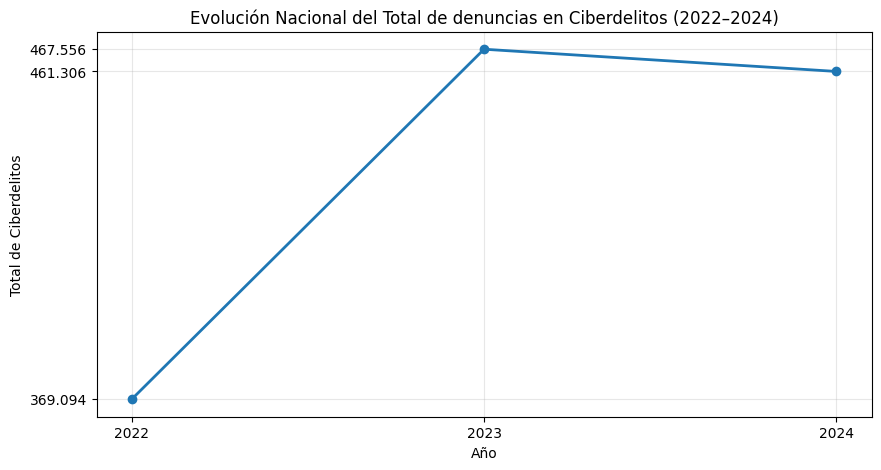

In [ ]:
#==============================================================================
#@title Evolución nacional del total de ciberdelitos
#==============================================================================

# 1. Agregación nacional por año
df_nacional = (
    df_cibercrimen.groupby('periodo')['Total_Hechos']
    .sum()
    .reset_index()
)

# 2. Formateo para etiquetas (puntos como separador de miles)
df_nacional['Total_Hechos_fmt'] = df_nacional['Total_Hechos'].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

# 3. Gráfico con matplotlib (compatible con GitHub)
plt.figure(figsize=(10, 5))
plt.plot(
    df_nacional['periodo'],
    df_nacional['Total_Hechos'],
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

# 4. Etiquetas y título
plt.title("Evolución Nacional del Total de denuncias en Ciberdelitos (2022–2024)", fontsize=12)
plt.xlabel("Año")
plt.ylabel("Total de Ciberdelitos")

# 5. Sustituir ticks del eje Y por formato con puntos
plt.gca().set_yticks(df_nacional['Total_Hechos'])
plt.gca().set_yticklabels(df_nacional['Total_Hechos_fmt'])

# 6. Ajustes finales
plt.grid(alpha=0.3)
plt.xticks(df_nacional['periodo'])

plt.show()


La gráfica muestra una **tendencia nacional creciente** de ciberdelitos entre 2022 y 2023, seguida de un **ligero descenso en 2024**. En conjunto, el periodo refleja un **incremento neto** del fenómeno respecto al punto de partida.

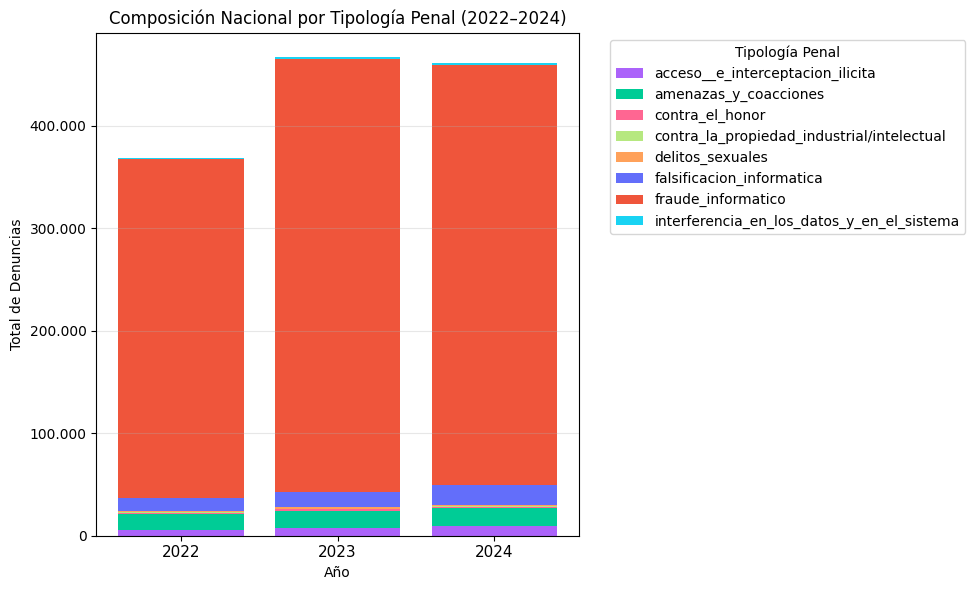

In [ ]:
#==============================================================================
#@title Composición Nacional por Tipología Penal (2022–2024)
#==============================================================================

# 1. Preparación de datos
df_grupos = (
    df_cibercrimen.groupby(['periodo', 'Grupo penal'])['Total_Hechos']
    .sum()
    .reset_index()
)

# 2. Pivot para gráfico apilado
df_pivot = df_grupos.pivot(index='periodo', columns='Grupo penal', values='Total_Hechos').fillna(0)

# 3. Convertir índice a enteros (por si acaso)
df_pivot.index = df_pivot.index.astype(int)

# 4. Colores oficiales
colores_ajustados = {
    "fraude_informatico": "#EF553B",
    "falsificacion_informatica": "#636EFA",
    "amenazas_y_coacciones": "#00CC96",
    "acceso__e_interceptacion_ilicita": "#AB63FA",
    "delitos_sexuales": "#FFA15A",
    "interferencia_en_los_datos_y_en_el_sistema": "#19D3F3",
    "contra_el_honor": "#FF6692",
    "contra_la_propiedad_industrial/intelectual": "#B6E880"
}

# 5. Gráfico apilado matplotlib
plt.figure(figsize=(10, 6))

bottom = None
for col in df_pivot.columns:
    plt.bar(
        df_pivot.index,
        df_pivot[col],
        bottom=bottom,
        label=col,
        color=colores_ajustados.get(col, "#999999")
    )
    bottom = df_pivot[col] if bottom is None else bottom + df_pivot[col]

# 6. Forzar años como enteros en el eje X
plt.xticks([2022, 2023, 2024], [2022, 2023, 2024], fontsize=11)

# 7. Título y etiquetas
plt.title("Composición Nacional por Tipología Penal (2022–2024)", fontsize=12)
plt.xlabel("Año")
plt.ylabel("Total de Denuncias")

# 8. Formato de miles con puntos
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

# 9. Leyenda
plt.legend(title="Tipología Penal", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


El fraude informático concentra **más del 85%** de los hechos y marca la tendencia nacional, con un pico en 2023 y ligera corrección en 2024. El resto de tipologías se mantienen estables, salvo la falsificación informática, que muestra el **mayor crecimiento relativo**. Para el modelado, la dinámica del fraude será el principal motor de la predicción 2025.

### FRAUDE INFORMÁTICO foco de inspección especializada:

Debido a que esta tipología concentra el mayor volumen de la cibercriminalidad en España y desvirtúa la escala del resto de delitos, se aisla este grupo estratégico para su análisis exclusivo:

---



| Grupo penal | Delitos incluidos según SEC | Grupo penal | Delitos incluidos según SEC |
| :--- | :--- | :--- | :--- |
| **fraude_<br>informatico** | estafas con tarjetas de crédito,<br>débito y cheques de viaje<br>otras estafas<br>estafas informáticas<br>estafa de inversores<br>estafa bancaria | **interferencia_<br>en_los_datos_y_<br>en_el_sistema** | ataques a datos o<br>programas informáticos<br>ataques a sistemas<br>informáticos<br>ataques informáticos<br>daños |


In [ ]:
#---------------------------------------------------------------
#@title Mapa Peso Fraude y Tasa Criminalidad Informático por Provincias 2022 - 2024
#---------------------------------------------------------------

# 1. Usar dataset maestro y FILTRAR SOLO FRAUDE
df = df_cibercrimen.copy()
df["codigo_ine"] = df["codigo_ine"].astype(str).str.zfill(2)

df = df[df["Grupo penal"] == "fraude_informatico"]   # ← CLAVE

# 2. Cargar GeoJSON local
path_geojson = os.path.join(path_data, "spain-provinces.geojson")
with open(path_geojson, encoding='utf-8') as f:
    geojson = json.load(f)

# 3. Desplazamiento de Canarias, se ajusta en el mapa para una mejor visualización
# Si las islas quedan muy altas, muy bajas o descentradas,
#se ajusta los parámetros de la función en la línea:
# geojson = mover_canarias(geojson, dx=5.5, dy=4.5, scale=1.0)
# dx: Mueve las islas a la derecha (positivo) o izquierda (negativo).
# dy: Mueve las islas hacia arriba (positivo) o hacia abajo (negativo).

def mover_canarias(geojson, dx=5.5, dy=4.5, scale=1.0):
    canarias = ["35", "38"]
    for feature in geojson["features"]:
        cod = feature["properties"]["cod_prov"]
        if cod in canarias:
            geom = feature["geometry"]
            if geom["type"] == "MultiPolygon":
                geom["coordinates"] = [
                    [
                        [[lon * scale + dx, lat * scale + dy] for lon, lat in ring]
                        for ring in poly
                    ]
                    for poly in geom["coordinates"]
                ]
            elif geom["type"] == "Polygon":
                geom["coordinates"] = [
                    [[lon * scale + dx, lat * scale + dy] for lon, lat in ring]
                    for ring in geom["coordinates"]
                ]
    return geojson

geojson = mover_canarias(geojson)

# 4. Selección del primer año
años = sorted(df["periodo"].unique())
año_inicial = años[0]
df_year = df[df["periodo"] == año_inicial]

# 5. Crear figura Variable Visual y Escala de Colores
# En la definición de px.choropleth:
# Cambiar la métrica a visualizar: Cambia color="Peso_Fraude" por color="Tasa_Criminalidad".
# Cambiar la paleta de colores: Modifica color_continuous_scale="Reds" por opciones como "Viridis", "Blues" o "YlOrRd".

fig = px.choropleth(
    df_year,
    geojson=geojson,
    locations="codigo_ine",
    featureidkey="properties.cod_prov",
    color="Peso_Fraude",
    hover_name="Provincias",
    hover_data={"Peso_Fraude": ":.2f", "Tasa_Criminalidad": ":.2f", "codigo_ine": False},
    color_continuous_scale="Reds",
)

# --- AJUSTES DE VISUALIZACIÓN ---
# Tamaño del Lienzo y Leyenda (Bloque update_layout)
# Dimensiones del mapa: Modifica width=1200 y height=900
# para cambiar el tamaño del gráfico en pantalla.
# Grosor y altura de la barra de color: Ajusta thickness=15 (ancho en píxeles)
# y len=0.5 (determina que la barra ocupe el 50% de la altura total).

fig.update_layout(
    title={
        "text": f"Peso y Tasa del Fraude Informático por Provincias ({año_inicial})",
        "x": 0.5,
        "y": 0.95,
        "xanchor": "center",
        "yanchor": "top",
        "font": dict(size=22)
    },
    coloraxis_colorbar=dict(
        title="Peso Fraude",
        thicknessmode="pixels", thickness=15,
        lenmode="fraction", len=0.5,
        yanchor="middle", y=0.5,
        x=0.92  # Mueve la barra ligeramente a la izquierda para que no se corte
    ),
    margin=dict(t=50, l=10, r=50, b=10), # Aumenta el margen derecho (r=50) para dar espacio a la barra
    # width=1200, BORRADO: Al quitarlo, Plotly se autoajusta al 100% del ancho de Colab
    height=800    #cambio a 800 para mantener una buena proporción sin scroll vertical
)

# Botón selector de año (Bloque updatemenus)
# Ubicación del botón desplegable: Modifica x=0.05 e y=0.90.
#El plano se mide de 0 a 1, por lo que estos valores sitúan el botón en
#la esquina superior izquierda del mapa.

botones = []
for año in años:
    df_temp = df[df["periodo"] == año]
    botones.append(dict(
        label=str(año),
        method="update",
        args=[
            {"z": [df_temp["Peso_Fraude"]], "locations": [df_temp["codigo_ine"]]},
            {"title": f"Peso del Fraude Informático por Provincia ({año})"}
        ]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=botones,
        direction="down",
        showactive=True,
        x=0.05,
        y=0.90,
        xanchor="left",
        yanchor="top"
    )]
)

# Ajuste geográfico
fig.update_geos(
    fitbounds="locations",
    visible=False,
    projection_scale=1
)

fig.show()


#---------------------------------------------------------------
# Exportaciones para GitHub y GitHub Pages
#---------------------------------------------------------------
os.makedirs("mapas_interactivos", exist_ok=True)

# Imagen estática (visible en GitHub)
# fig.write_image("mapas_interactivos/mapa_fraude.png")

# Versión interactiva (para GitHub Pages)
fig.write_html("mapas_interactivos/mapa_fraude.html", include_plotlyjs="cdn")


**Análisis Peso Fraude y Tasa Criminalidad 2022 - 20224**
- **2022**: Inicio del periodo con una tasa media de criminalidad de 6.65 y un peso del fraude del 88.3%.
- **2023:** Año de mayor incidencia, donde la tasa sube a 8.41 y el fraude alcanza su pico máximo (89.35% de media), destacando Barcelona con un 97.33%.
- **2024**: Ligera estabilización a la baja en la tasa (8.10), aunque el fraude sigue siendo masivo (87.59%), con Girona relevando el liderazgo de concentración.

En resumen, el mapa muestra una expansión y consolidación crítica del fraude como el motor principal de la criminalidad informática en España.

Puedes añadir este bloque directamente debajo de tu nota de análisis. Está estructurado de forma muy directa y sin tecnicismos para que cualquier persona que mire el mapa entienda el significado exacto de ambas métricas en ese mismo instante:

---

**Glosario de Métricas del Mapa**

Para interpretar correctamente los datos y los colores de las provincias, ten en cuenta qué mide cada indicador:

* **Peso Fraude (%):** Mide la **concentración** del delito. Es el porcentaje que representan las estafas e informática fraudulenta sobre el total de ciberdelitos de esa provincia.
* *¿Qué significa?* Si una provincia tiene un 90%, significa que de cada 10 ciberdelitos que ocurren allí, 9 son fraudes y solo 1 pertenece a otras tipologías (como amenazas o delitos sexuales). Por eso los colores del mapa van en consonancia con esta métrica.


* **Tasa Criminalidad (x 1.000 hab.):** Mide la **frecuencia** o impacto real en la población. Es el número de fraudes informáticos registrados por cada 1.000 habitantes en esa provincia.
* *¿Qué significa?* Permite comparar provincias de tamaños muy diferentes de forma justa. Si una provincia tiene una tasa de 8.4, significa que se registran algo más de 8 fraudes al año por cada mil habitantes.

In [ ]:
# ==============================================================================
#@title Mapa Análisis de Variación Interanual Fraude (2023 - 2024)
# Visualización de tasas de crecimiento
# ==============================================================================


# 1. USAR SOLO EL DATASET MAESTRO Y SOLO FRAUDE INFORMÁTICO
df = df_cibercrimen.copy()
df["codigo_ine"] = df["codigo_ine"].astype(str).str.zfill(2)

df = df[df["Grupo penal"] == "fraude_informatico"]   # ← CLAVE

# Filtrar solo años con VAR_pct válido
df_var = df[df["periodo"].isin([2023, 2024])].copy()

# 2. CARGAR GEOJSON LOCAL
path_geojson = os.path.join(path_data, "spain-provinces.geojson")
with open(path_geojson, encoding='utf-8') as f:
    geojson = json.load(f)

# Mover Canarias
def mover_canarias(geojson, dx=5.5, dy=4.5, scale=1.0):
    canarias = ["35", "38"]
    for feature in geojson["features"]:
        cod = feature["properties"]["cod_prov"]
        if cod in canarias:
            geom = feature["geometry"]
            if geom["type"] == "MultiPolygon":
                geom["coordinates"] = [
                    [
                        [[lon * scale + dx, lat * scale + dy] for lon, lat in ring]
                        for ring in poly
                    ]
                    for poly in geom["coordinates"]
                ]
            elif geom["type"] == "Polygon":
                geom["coordinates"] = [
                    [[lon * scale + dx, lat * scale + dy] for lon, lat in ring]
                    for ring in geom["coordinates"]
                ]
    return geojson

geojson = mover_canarias(geojson)

# 3. AÑO INICIAL (2023)
años_var = sorted(df_var["periodo"].unique())
año_inicial = años_var[0]
df_inicial = df_var[df_var["periodo"] == año_inicial]

# 4. MAPA
fig = px.choropleth(
    df_inicial,
    geojson=geojson,
    locations="codigo_ine",
    featureidkey="properties.cod_prov",
    color="VAR_pct",
    hover_name="Provincias",
    hover_data={
        "VAR_pct": ":.2f",
        "Peso_Fraude": ":.2f",
        "codigo_ine": False
    },
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0
)

# 5. BOTONES (2023 y 2024)
botones = []
for año in años_var:
    df_temp = df_var[df_var["periodo"] == año]
    botones.append(dict(
        label=f"Variación {año}",
        method="update",
        args=[
            {"z": [df_temp["VAR_pct"]], "locations": [df_temp["codigo_ine"]]},
            {"title": f"Variación Interanual del Fraude Informático ({año}) %"}
        ]
    ))

# 6. DISEÑO FINAL
fig.update_layout(
    title={
        "text": f"Variación Interanual del Fraude Informático ({año_inicial}) %",
        "x": 0.5, "y": 0.95,
        "xanchor": "center",
        "yanchor": "top",
        "font": dict(size=22)
    },
    coloraxis_colorbar=dict(
        title="Var %",
        thicknessmode="pixels", thickness=15,
        lenmode="fraction", len=0.5,
        yanchor="middle", y=0.5,
        x=0.92  # Mueve la barra de escala hacia adentro para evitar que se corte
    ),
    margin=dict(t=80, l=10, r=50, b=10), # ← Añadimos margen a la derecha (r=50) para la barra
    # width=1300, BORRADO: Al no fijar el ancho, Plotly ocupa el 100% de la celda de Colab de forma responsiva
    height=800,
    updatemenus=[dict(
        buttons=botones,
        direction="down",
        x=0.05, y=0.90,
        xanchor="left",
        yanchor="top",
        showactive=True
    )]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

# ---------------------------------------------------------------
# Exportación SOLO HTML (PNG no funciona en Python 3.12)
# ---------------------------------------------------------------
os.makedirs("mapas_interactivos", exist_ok=True)
fig.write_html("mapas_interactivos/mapa_var_fraude.html", include_plotlyjs="cdn")


**Análisis VAR %**

Este segundo mapa, basado en la métrica VAR_pct, visualiza la velocidad de cambio (aceleración o freno) del fraude informático entre 2023 y 2024:

- **2023:** El año de la explosión. El mapa se tiñe de rojo intenso. Se registra un crecimiento medio masivo del 29.9% respecto al año anterior. Destacan provincias como Guadalajara (+99.6%) y Granada (+91%), donde el fraude prácticamente se duplicó en solo doce meses. Solo Ourense y La Rioja lograron reducir su incidencia en este periodo.

- **2024:** La fase de corrección/estabilización. El mapa vira hacia el azul. Tras el pico de 2023, se observa un descenso medio del -2.2%. Provincias como Soria (-20.3%) y Cuenca (-14.8%) lideran esta desescalada. No obstante, el crecimiento persiste en zonas puntuales como Almería (+18.4%) y Lugo (+13.3%).

**Conclusión visual:** Mientras que el primer mapa mostraba que el fraude es omnipresente, este segundo mapa revela que, tras un 2023 de crecimiento descontrolado, 2024 presenta una tendencia hacia la saturación o ligero retroceso en la mayoría del territorio.

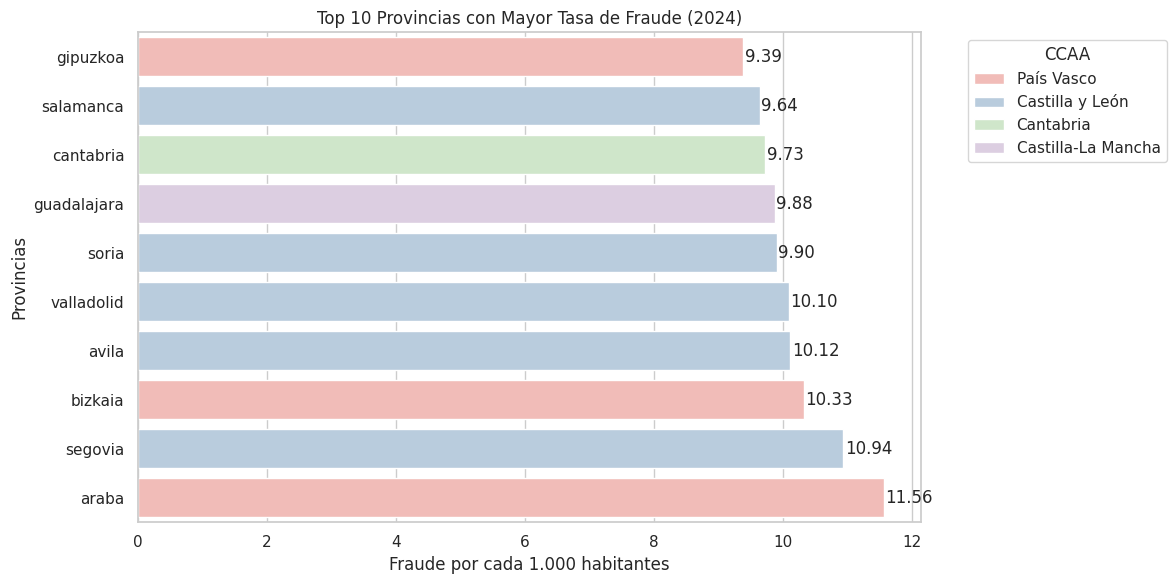

In [ ]:
# ==============================================================================
#@title Top 10 Provincias con Mayor Tasa de Fraude (2024) -
# ==============================================================================

# 1. Filtrar solo fraude informático
df = df_cibercrimen.copy()
df = df[df["Grupo penal"] == "fraude_informatico"]

# 2. Top 10 por tasa en 2024
top10 = (
    df[df["periodo"] == 2024]
    .nlargest(10, "Tasa_Criminalidad")
    .sort_values("Tasa_Criminalidad", ascending=True)
)

# 3. Estilo
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

# 4. Gráfico horizontal
ax = sns.barplot(
    data=top10,
    x="Tasa_Criminalidad",
    y="Provincias",
    hue="CCAA",
    palette="Pastel1",
    dodge=False
)

# 5. Etiquetas numéricas
for i, v in enumerate(top10["Tasa_Criminalidad"]):
    plt.text(v + 0.02, i, f"{v:.2f}", va="center")

# 6. Títulos y ajustes
plt.title("Top 10 Provincias con Mayor Tasa de Fraude (2024)", fontsize=12)
plt.xlabel("Fraude por cada 1.000 habitantes")
plt.ylabel("Provincias")
plt.legend(title="CCAA", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

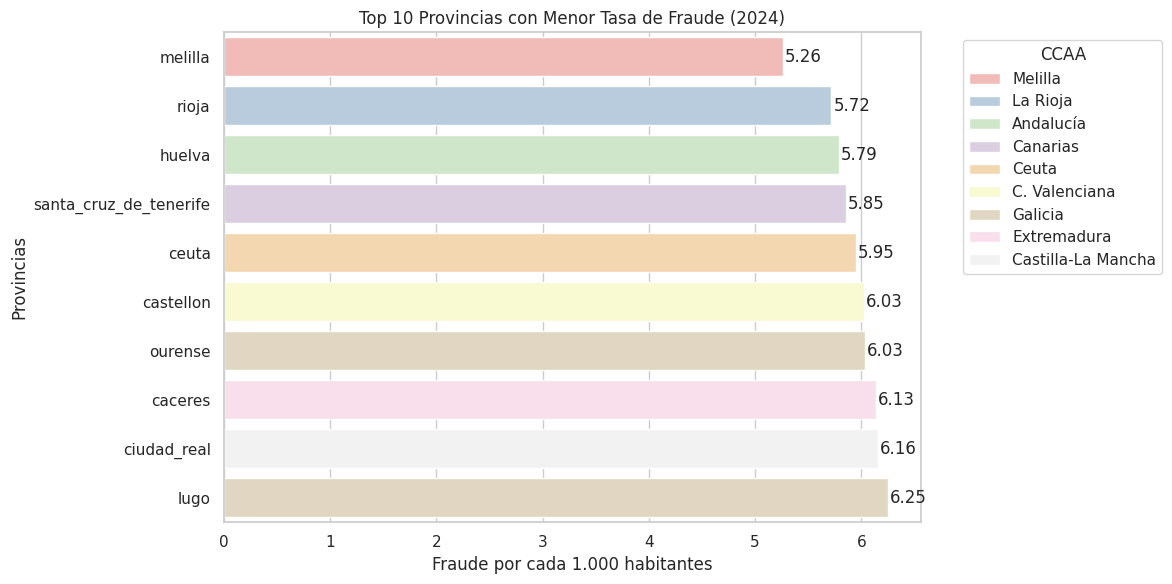

In [ ]:
# ==============================================================================
#@title Top 10 Provincias con Menor Tasa de Fraude (2024) -
# ==============================================================================

# 1. Filtrar solo fraude informático
df = df_cibercrimen.copy()
df = df[df["Grupo penal"] == "fraude_informatico"]

# 2. Top 10 con menor tasa en 2024
bottom10 = (
    df[df["periodo"] == 2024]
    .nsmallest(10, "Tasa_Criminalidad")
    .sort_values("Tasa_Criminalidad", ascending=True)
)

# 3. Estilo
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

# 4. Gráfico horizontal
ax = sns.barplot(
    data=bottom10,
    x="Tasa_Criminalidad",
    y="Provincias",
    hue="CCAA",
    palette="Pastel1",
    dodge=False
)

# 5. Etiquetas numéricas
for i, v in enumerate(bottom10["Tasa_Criminalidad"]):
    plt.text(v + 0.02, i, f"{v:.2f}", va="center")

# 6. Títulos y ajustes
plt.title("Top 10 Provincias con Menor Tasa de Fraude (2024)", fontsize=12)
plt.xlabel("Fraude por cada 1.000 habitantes")
plt.ylabel("Provincias")
plt.legend(title="CCAA", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#**Análisis del Impacto del Fraude Informático por Provincias (2024)**

Para entender estos datos, recuerda que la **Tasa de Criminalidad** indica cuántos fraudes informáticos se denuncian al año **por cada 1.000 habitantes** de esa provincia. Esto nos permite comparar zonas grandes y pequeñas de forma totalmente justa.

---

**Top Provincias con Mayor Frecuencia de Fraude**

*(Donde es más común ser víctima de una estafa informática)*

* **Araba/Álava (11,6):** Lidera el ranking nacional. Esto significa que casi 12 de cada 1.000 residentes sufrieron un fraude en 2024, situándose como la zona de mayor peligro estadístico.
* **Castilla y León:** Se consolida como la comunidad con más puntos críticos concentrados, destacando **Segovia (10,9)**, **Ávila (10,1)** y **Valladolid (10,1)**.
* **Bizkaia (10,3):** Confirma que el País Vasco presenta una actividad delictiva informática muy elevada.
* **Guadalajara (9,9) y Cantabria (9,7):** Cierran el grupo con las densidades de estafas más altas del país.

---

**Top Provincias con Menor Frecuencia de Fraude**

*(Donde se registra una menor incidencia por habitante)*

* **Melilla (5,3):** Registra la cifra más baja de toda España (apenas 5 denuncias por cada 1.000 personas).
* **La Rioja (5,7) y Huelva (5,8):** Se mantienen inmediatamente después como zonas con un impacto notablemente inferior a la media.
* **Rango seguro (5,9 – 6,2):** Provincias como **Ourense, Lugo, Las Palmas, Ceuta y Ciudad Real** logran contener el impacto del fraude en la parte baja de la tabla.

---

**Conclusión Clave**

La brecha entre los dos extremos es drástica: una persona que vive en **Araba (11,6)** tiene **el doble de probabilidades** de sufrir un fraude informático que una persona que reside en **Melilla (5,3)**. El riesgo real está muy condicionado por la provincia geográfica de residencia.

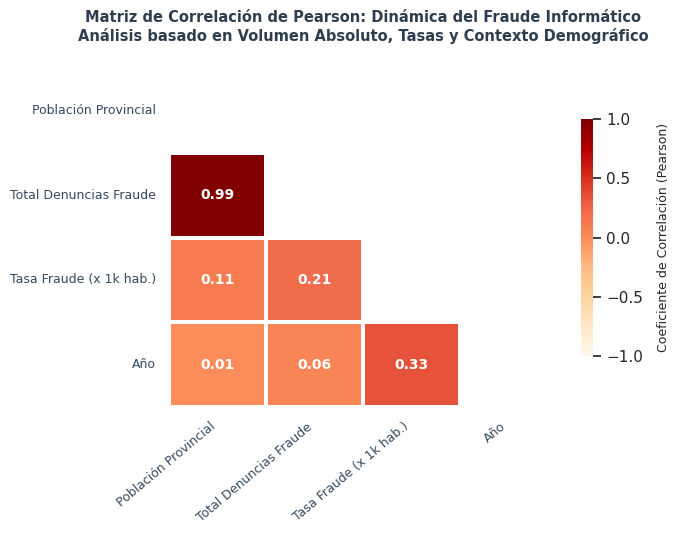

In [ ]:
# ==============================================================================
# @title Matriz de Correlación — Solo Fraude Informático
# ==============================================================================

# 1. Filtrar dataset: Seleccionamos EXCLUSIVAMENTE el fraude informático
df_fraude = df_cibercrimen[df_cibercrimen['Grupo penal'] == "fraude_informatico"].copy()

# 2. Pivotar los datos para cruzar las variables numéricas clave por provincia y año
df_pivot_fraude = df_fraude.pivot_table(
    index=['Provincias', 'periodo'],
    values=['Total_Hechos', 'Poblacion_Provincial', 'Tasa_Criminalidad'],
    aggfunc='sum'
).reset_index()

# Renombrar columnas para un acabado profesional
df_pivot_fraude.rename(columns={
    'Poblacion_Provincial': 'Población Provincial',
    'Total_Hechos': 'Total Denuncias Fraude',
    'Tasa_Criminalidad': 'Tasa Fraude (x 1k hab.)',
    'periodo': 'Año'
}, inplace=True)

# Seleccionamos las variables numéricas finales para la correlación
variables_fraude = ['Población Provincial', 'Total Denuncias Fraude', 'Tasa Fraude (x 1k hab.)', 'Año']
df_num_fraude = df_pivot_fraude[variables_fraude].copy()

# 3. Calcular la matriz de correlación de Pearson
matriz_corr_fraude = df_num_fraude.corr(method='pearson')

# 4. Configuración del diseño gráfico (Formato y dimensiones optimizadas para Notebook/GitHub)
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 5.5), dpi=100) # Ajuste de proporciones para evitar cortes laterales
sns.set_theme(style="white")

# Máscara para ocultar el triángulo superior duplicado
mask = np.triu(np.ones_like(matriz_corr_fraude, dtype=bool))

# Paleta secuencial cálida
cmap = sns.color_palette("OrRd", as_cmap=True)

# Dibujar el mapa de calor (Heatmap)
ax = sns.heatmap(
    matriz_corr_fraude,
    mask=mask,
    cmap=cmap,
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=1.5,
    cbar_kws={"shrink": 0.7},  # Barra lateral estilizada y equilibrada
    annot_kws={"size": 10, "weight": "semibold"} # Números interiores legibles
)

# Asignar el título a la barra de color de forma segura
if ax.collections[0].colorbar:
    ax.collections[0].colorbar.set_label("Coeficiente de Correlación (Pearson)", fontsize=9, labelpad=10)

# 5. Personalización Avanzada de Títulos y Ejes (Solución definitiva al solapamiento)
# ------------------------------------------------------------------------------
plt.title(
    "Matriz de Correlación de Pearson: Dinámica del Fraude Informático\n"
    "Análisis basado en Volumen Absoluto, Tasas y Contexto Demográfico",
    fontsize=10.5, pad=20, weight='bold', color='#2c3e50'
)

# Ajuste fino de la inclinación y anclaje de los textos del eje X
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=40,
    ha='right',
    fontsize=9,
    color='#34495e',
    weight='medium'
)

# Ajuste sutil de las etiquetas del eje Y
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9,
    color='#34495e',
    weight='medium'
)

plt.tight_layout()
plt.show()

#**Resumen: Dinámica del Fraude Informático**

La matriz revela una lógica delictiva muy diferente a la de otros ciberdelitos:

* **Correlación Población-Volumen (0.99):** Es la relación más fuerte del análisis. El **Total de Denuncias por Fraude** depende casi exclusivamente del tamaño de la provincia; a más población, más volumen bruto de estafas, lo cual es lógico dado que el fraude masivo busca alcanzar a la mayor cantidad posible de víctimas potenciales.
* **Desacople de la Tasa de Criminalidad (0.11 y 0.21):** Curiosamente, la **Tasa de Fraude** (delitos por cada 1.000 habitantes) presenta una correlación muy baja tanto con la población como con el volumen de denuncias. Esto significa que **el fraude informático no entiende de fronteras ni de tamaños**: una provincia pequeña puede tener una tasa de fraude tan elevada como una gran capital, ya que el atacante opera de forma remota y deslocalizada.
* **Factor Temporal (0.33):** La correlación positiva con el **Año (0.33)** indica una tendencia al alza constante. A medida que avanzan los periodos, la tasa de fraude ha ido aumentando de forma generalizada en todo el territorio nacional, independientemente de la población de la provincia.

**En resumen:** El fraude informático es el ciberdelito más "democrático" y menos dependiente del contexto local. Mientras que otros delitos se concentran geográficamente, el fraude crece de forma constante y uniforme en todo el país, afectando a las provincias por igual sin importar su densidad de población.

#**VISUALIZACIÓN OTROS CIBERDELITOS**

Como se ha visto anteriormente, el Fraude informatico eclipsa el resto de ciberdelitos. A continuación se realizar una visualización sólo para otros ciberdelitos

| Grupo penal | Delitos incluidos según SEC | Grupo penal | Delitos incluidos según SEC |
| :--- | :--- | :--- | :--- |
| **amenazas_y_coacciones** | Amenazas y coacciones realizadas<br>por medios digitales, hostigamiento,<br>chantaje, extorsión sin componente sexual. | **delitos_sexuales** | Grooming, sextorsión, difusión no<br>consentida de contenido sexual,<br>captación de menores, difusión<br>ilícita de imágenes íntimas. |
| **falsificacion_informatica** | Manipulación de datos, alteración de<br>documentos electrónicos, creación de<br>identidades falsas, falsificación de tarjetas,<br>clonación digital, manipulación de credenciales. | **contra_el_honor** | Injurias y calumnias online, difamación,<br>publicaciones que dañan la reputación,<br>suplantación para perjudicar la imagen. |
| **acceso__e_interceptacion_ilicita** | Acceso no autorizado a sistemas,<br>intrusión, hacking, interceptación de<br>comunicaciones, captación ilícita de datos. | **contra_la_propiedad_industrial<br>/intelectual** | Piratería digital, distribución ilícita de<br>contenidos protegidos, infracción de<br>derechos de autor en plataformas, uso no<br>autorizado de marcas en entornos digitales. |
| **interferencia_en_los_datos_<br>y_en_el_sistema** | Borrado, deterioro o bloqueo de datos,<br>ataques DDoS, sabotaje digital, ransomware<br>sin componente de fraude directo. | | |

In [ ]:
# ==============================================================================
# @title Mapa Análisis de tasa de criminalidad de Otros Ciberdelitos (2022 - 2024)
#Se analizara el total de la tasa de cibercriminalidad por provincia ya que
#hay categorias que no tienen delitos y no viable la visualización en este formato
# ==============================================================================

# 1. PREPARACIÓN DE DATOS DESDE df_cibercrimen
# ------------------------------------------------------------------------------
df = df_cibercrimen.copy()
df["codigo_ine"] = df["codigo_ine"].astype(str).str.zfill(2)

# Excluir fraude informático obligatoriamente para quedarnos con el "Resto"
df = df[df["Grupo penal"] != "fraude_informatico"]

# Agregamos DIRECTAMENTE por provincia y año para consolidar el bloque total
df_resumen = (
    df.groupby(["codigo_ine", "Provincias", "periodo", "Poblacion_Provincial"])
      .agg(Total_Hechos_Otros=("Total_Hechos", "sum"))
      .reset_index()
)

# Calculamos la Tasa de Criminalidad robusta del bloque por cada 1.000 habitantes
df_resumen["Tasa_Criminalidad"] = (df_resumen["Total_Hechos_Otros"] / df_resumen["Poblacion_Provincial"]) * 1000

# 2. CARTOGRAFÍA Y ORDENACIÓN ESTABLE
# ------------------------------------------------------------------------------
with open(path_geojson, encoding='utf-8') as f:
    geojson = json.load(f)

geojson = mover_canarias(geojson)

# Extraemos el orden exacto del GeoJSON para forzar el merge
provincias_geojson = [feature["properties"]["cod_prov"] for feature in geojson["features"]]
df_provincias_maestro = pd.DataFrame({"codigo_ine": provincias_geojson})

# 3. CONFIGURACIÓN DEL MAPA
# ------------------------------------------------------------------------------
años = sorted(df_resumen["periodo"].unique())  # 2022, 2023, 2024
fig = go.Figure()
capas_info = []

# 4. CONSTRUCCIÓN DE CAPAS (Una única capa limpia por año)
# ------------------------------------------------------------------------------
for a in años:
    df_año = df_resumen[df_resumen["periodo"] == a].copy()

    # Cruzamos con el maestro de 52 provincias para asegurar estabilidad absoluta
    df_mapeado = pd.merge(df_provincias_maestro, df_año, on="codigo_ine", how="left")
    df_mapeado["Tasa_Criminalidad"] = df_mapeado["Tasa_Criminalidad"].fillna(0)
    df_mapeado["Total_Hechos_Otros"] = df_mapeado["Total_Hechos_Otros"].fillna(0)
    df_mapeado["Poblacion_Provincial"] = df_mapeado["Poblacion_Provincial"].fillna(0)
    df_mapeado["Provincias"] = df_mapeado["Provincias"].fillna("Sin datos")

# Formateamos los números para el recuadro interactivo (hover)
    hover_textos = []
    for _, row in df_mapeado.iterrows():
        texto = (
            f"<b>{row['Provincias']}</b><br><br>"
            f"Año: {a}<br>"
            f"Total denuncias: {int(row['Total_Hechos_Otros']):,}<br>"  # ← Cambiado aquí
            f"Población: {int(row['Poblacion_Provincial']):,}<br>"
            f"<b>Tasa Criminalidad: {row['Tasa_Criminalidad']:.2f} x 1k hab.</b>" # ← Eliminado el <extra></extra>
        )
        hover_textos.append(texto)

    # Añadimos la capa anual al mapa
    fig.add_trace(go.Choropleth(
        geojson=geojson,
        locations=df_mapeado["codigo_ine"],
        featureidkey="properties.cod_prov",
        z=df_mapeado["Tasa_Criminalidad"],
        text=hover_textos,            # Pasamos los textos ya pre-construidos
        hoverinfo="text",             # Obligamos a Plotly a usar exclusivamente nuestro diseño limpio
        colorscale="Plasma",
        visible=False,
        colorbar=dict(
            title="Tasa x 1k",
            thickness=15,
            len=0.5,
            y=0.5,
            thicknessmode="pixels",
            lenmode="fraction"
        ),
        name=str(a)
    ))

    capas_info.append({"año": a, "titulo": f"Tasa de Criminalidad: Resto de Ciberdelitos ({a})"})

# Hacemos visible el año más reciente (2024) por defecto
index_defecto = len(años) - 1
fig.data[index_defecto].visible = True

# 5. UN SÓLO BOTÓN DESPLEGABLE: EXCLUSIVAMENTE PARA EL AÑO
# ------------------------------------------------------------------------------
botones_años = []
for i, a in enumerate(años):
    mascara = [str(a) == trace.name for trace in fig.data]

    botones_años.append(dict(
        label=f"Año {a}",
        method="update",
        args=[
            {"visible": mascara},
            {"title.text": capas_info[i]["titulo"]} # Actualiza el título del mapa en sincronía
        ]
    ))

# 6. LAYOUT FINAL (Limpio, responsivo y sin elementos que colisionen)
# ------------------------------------------------------------------------------
fig.update_layout(
    title={
        "text": capas_info[index_defecto]["titulo"],
        "x": 0.5, "y": 0.96,
        "xanchor": "center", "yanchor": "top",
        "font": dict(size=18)
    },
    margin=dict(t=120, l=10, r=50, b=10),
    height=800,
    updatemenus=[dict(
        buttons=botones_años,
        direction="down",
        showactive=True,
        x=0.02, y=0.94,
        xanchor="left", yanchor="top"
    )]
)

fig.add_annotation(x=0.02, y=0.98, text="<b>Seleccionar Año de Análisis:</b>", showarrow=False, xref="paper", yref="paper")

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

# 7. EXPORTACIÓN INTERACTIVA
# ------------------------------------------------------------------------------
os.makedirs("mapas_interactivos", exist_ok=True)
fig.write_html("mapas_interactivos/mapa_delitos_no_fraude.html", include_plotlyjs="cdn")

**Evolución del Resto de Ciberdelitos (2022 - 2024)**

Al excluir fraude informático se observa el siguiente comportamiento geográfico:

* **El foco crítico en Salamanca (2024):** En el último año, **Salamanca** se consolida de forma indiscutible como la provincia con mayor densidad de este bloque de delitos en toda España, destacando con el color amarillo más brillante del mapa (alcanzando su pico entre **1,6 y 1,8 denuncias por cada 1.000 habitantes**).
* **El "encendido" interanual:** Si comparamos los mapas de 2022, 2023 y 2024, se observa una transición clarísima. El país pasa de estar dominado por tonos morados oscuros (baja incidencia en 2022) a llenarse de tonos rosas y naranjas en 2024, lo que demuestra un incremento progresivo y generalizado de estas denuncias año tras año.
* **Zonas de mayor resistencia:** El noreste peninsular (Cataluña y Aragón) junto con la mitad sur (Andalucía y Murcia) se mantienen de forma muy estable a lo largo del trienio en las franjas más oscuras de la escala, con tasas que apenas superan el **0,6 - 0,8**.

**Conclusión:** El riesgo de sufrir ciberdelitos ajenos a las estafas económicas no es uniforme; se ha concentrado con especial fuerza en el oeste peninsular, teniendo a **Salamanca** como el punto de mayor actividad delictiva por habitante en 2024.

In [ ]:
# ==============================================================================
# @title Mapa Análisis de Variación Interanual: Resto de Ciberdelitos (2022 - 2024)
# ==============================================================================

# 1. PREPARACIÓN DE DATOS Y CÁLCULO DE TASAS
# ------------------------------------------------------------------------------
df = df_cibercrimen.copy()
df["codigo_ine"] = df["codigo_ine"].astype(str).str.zfill(2)

# Excluir fraude informático obligatoriamente
df = df[df["Grupo penal"] != "fraude_informatico"]

# Agrupación general por provincia y año
df_resumen = (
    df.groupby(["codigo_ine", "Provincias", "periodo", "Poblacion_Provincial"])
      .agg(Total_Hechos_Otros=("Total_Hechos", "sum"))
      .reset_index()
)
df_resumen["Tasa_Criminalidad"] = (df_resumen["Total_Hechos_Otros"] / df_resumen["Poblacion_Provincial"]) * 1000

# 2. CÁLCULO ESTRICTO DE LA VARIACIÓN INTERANUAL (%)
# ------------------------------------------------------------------------------
# Pivotamos la tabla para tener los años en columnas y calcular los porcentajes fácilmente
df_pivot = df_resumen.pivot(index=["codigo_ine", "Provincias"], columns="periodo", values="Tasa_Criminalidad").reset_index()

# Calculamos la variación porcentual: ((Tasa_Actual - Tasa_Anterior) / Tasa_Anterior) * 100
df_pivot["Var_22_23"] = ((df_pivot[2023] - df_pivot[2022]) / df_pivot[2022]) * 100
df_pivot["Var_23_24"] = ((df_pivot[2024] - df_pivot[2023]) / df_pivot[2023]) * 100

# Extraemos también los hechos absolutos de cada año para incluirlos en el hover
df_hechos = df_resumen.pivot(index="codigo_ine", columns="periodo", values="Total_Hechos_Otros").reset_index()
df_pivot = df_pivot.merge(df_hechos, on="codigo_ine", suffixes=('_tasa', '_hechos'))

# 3. CARTOGRAFÍA Y ORDENACIÓN ESTABLE
# ------------------------------------------------------------------------------
with open(path_geojson, encoding='utf-8') as f:
    geojson = json.load(f)

geojson = mover_canarias(geojson)

provincias_geojson = [feature["properties"]["cod_prov"] for feature in geojson["features"]]
df_provincias_maestro = pd.DataFrame({"codigo_ine": provincias_geojson})

# Unimos el maestro con nuestras variaciones calculadas para fijar las 52 provincias
df_mapeado_total = pd.merge(df_provincias_maestro, df_pivot, on="codigo_ine", how="left")

# 4. CONFIGURACIÓN DEL MAPA Y CAPAS
# ------------------------------------------------------------------------------
fig = go.Figure()

# Definimos los dos periodos de variación a renderizar
periodos = [
    {"col_var": "Var_22_23", "año_ant": 2022, "año_act": 2023, "col_hechos_act": "2023_hechos", "id": "22_23"},
    {"col_var": "Var_23_24", "año_ant": 2023, "año_act": 2024, "col_hechos_act": "2024_hechos", "id": "23_24"}
]

capas_info = []

for p in periodos:
    # Rellenamos nulos por si alguna provincia no registrara actividad en algún año
    valles_var = df_mapeado_total[p["col_var"]].fillna(0)
    hechos_act = df_mapeado_total[p["col_hechos_act"]].fillna(0)
    nombres_prov = df_mapeado_total["Provincias"].fillna("Sin datos")

    hover_textos = []
    for idx, row in df_mapeado_total.iterrows():
        val_var = row[p["col_var"]]
        # Formateamos el signo (+ o -) del porcentaje para que sea más legible
        signo = "+" if val_var > 0 else ""

        texto = (
            f"<b>{row['Provincias']}</b><br><br>"
            f"Periodo: {p['año_ant']} ➔ {p['año_act']}<br>"
            f"Total denuncias ({p['año_act']}): {int(row[p['col_hechos_act']]):,}<br>"
            f"<b>Variación Interanual: {signo}{val_var:.2f}%</b><extra></extra>"
        )
        hover_textos.append(texto)

    # Añadimos la capa correspondiente a la figura
    fig.add_trace(go.Choropleth(
        geojson=geojson,
        locations=df_mapeado_total["codigo_ine"],
        featureidkey="properties.cod_prov",
        z=valles_var,
        text=hover_textos,
        hoverinfo="text",
        colorscale="RdBu",  # Escala Divergente: Azul (baja), Blanco (estable), Rojo (sube)
        reversescale=True,   # Invertimos para que el Rojo represente el incremento del delito
        zmid=0,             # Forzamos que el centro exacto de la escala de color sea el 0%
        visible=False,
        colorbar=dict(
            title="Variación %",
            thickness=15,
            len=0.5,
            y=0.5,
            ticksuffix="%",
            thicknessmode="pixels",
            lenmode="fraction"
        ),
        name=p["id"]
    ))

    capas_info.append({"id": p["id"], "titulo": f"Variación Interanual del Resto de Ciberdelitos ({p['año_ant']} vs {p['año_act']})"})

# Hacemos visible el periodo más reciente por defecto (2023 vs 2024)
fig.data[1].visible = True

# 5. BOTÓN DESPLEGABLE DE SELECCIÓN DE PERIODO
# ------------------------------------------------------------------------------
botones_periodos = []
for i, p in enumerate(periodos):
    mascara = [p["id"] == trace.name for trace in fig.data]

    botones_periodos.append(dict(
        label=f"Evolución {p['año_ant']} ➔ {p['año_act']}",
        method="update",
        args=[
            {"visible": mascara},
            {"title.text": capas_info[i]["titulo"]}
        ]
    ))

# 6. LAYOUT FINAL
# ------------------------------------------------------------------------------
fig.update_layout(
    title={
        "text": capas_info[1]["titulo"],
        "x": 0.5, "y": 0.96,
        "xanchor": "center", "yanchor": "top",
        "font": dict(size=18)
    },
    margin=dict(t=120, l=10, r=50, b=10),
    height=800,
    updatemenus=[dict(
        buttons=botones_periodos,
        direction="down",
        showactive=True,
        x=0.02, y=0.94,
        xanchor="left", yanchor="top"
    )]
)

fig.add_annotation(x=0.02, y=0.98, text="<b>Seleccionar Periodo Evolutivo:</b>", showarrow=False, xref="paper", yref="paper")

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

# 7. EXPORTACIÓN INTERACTIVA
# ------------------------------------------------------------------------------
os.makedirs("mapas_interactivos", exist_ok=True)
fig.write_html("mapas_interactivos/mapa_variacion_no_fraude.html", include_plotlyjs="cdn")

**Variación Interanual del Resto de Ciberdelitos (2022 - 2024)**

Al analizar el crecimiento porcentual año a año de las denuncias por habitante (excluyendo las estafas), los datos reales muestran dos etapas muy marcadas en el país:

* **Periodo 2022 ➔ 2023 (Crecimiento Generalizado):** Este año estuvo marcado por un fuerte repunte en la mayor parte de España (provincias en color rojo). La gran mayoría de los territorios sufrieron incrementos de dos dígitos en sus tasas delictivas del bloque, consolidando la expansión inicial de estas tipologías.
* **Periodo 2023 ➔ 2024 (Frenazo y Desaceleración):** El último año muestra un escenario radicalmente opuesto. El mapa se "enfría" y se llena de tonos azules (descensos), lo que demuestra que en gran parte de España las denuncias de este bloque bajaron o se estabilizaron respecto al año anterior.
* **El caso de Salamanca:** Su posición como líder en tasa de criminalidad en 2024 se explica perfectamente al mirar su evolución: mientras casi toda España frenaba o reducía sus cifras entre 2023 y 2024, Salamanca se mantuvo en la zona de crecimiento positivo, desmarcándose de la tendencia de contención nacional.

**Conclusión:** Tras un preocupante repunte general de ciberdelitos interpersonales y técnicos en 2023, el año 2024 ha traído un respiro con descensos generalizados en la mayor parte de las provincias españolas, con contadas excepciones geográficas.

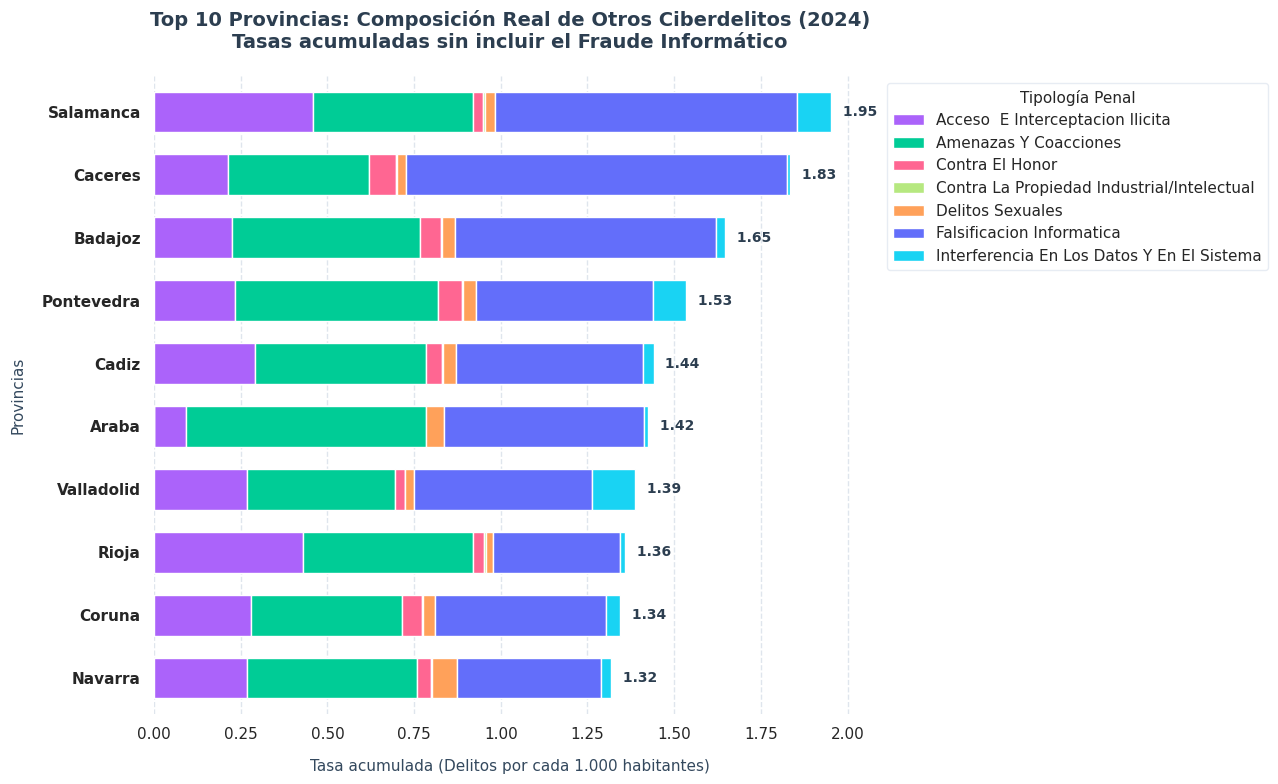

In [ ]:
# ==============================================================================
#@title Top 10 Mayor Otros Ciberdelitos - Provincias 2024
# ==============================================================================

# 1. Filtrar dataset maestro excluyendo fraude
df_otrosciber = df_cibercrimen[df_cibercrimen['Grupo penal'] != "fraude_informatico"].copy()

# 2. Agrupar por provincia (sumando todas las tipologías excepto fraude)
df_prov_total = (
    df_otrosciber[df_otrosciber['periodo'] == 2024]
    .groupby(['Provincias', 'CCAA'])['Tasa_Criminalidad']
    .sum()
    .reset_index()
)

# 3. Obtener las 10 provincias con mayor tasa total
top10_prov = df_prov_total.nlargest(10, 'Tasa_Criminalidad')['Provincias'].tolist()

# 4. Filtrar dataset desglosado para el gráfico stacked
df_top10 = df_otrosciber[
    (df_otrosciber['periodo'] == 2024) &
    (df_otrosciber['Provincias'].isin(top10_prov))
].copy()

# 5. Preparar datos pivotados para gráfico stacked
df_pivot = df_top10.pivot_table(
    index='Provincias',
    columns='Grupo penal',
    values='Tasa_Criminalidad',
    aggfunc='sum',
    fill_value=0
).loc[top10_prov]  # Mantiene el orden del top 10

# 6. ASIGNACIÓN DE TU PALETA DE COLORES OFICIALES
# ------------------------------------------------------------------------------
colores_ajustados = {
    "fraude_informatico": "#EF553B",
    "falsificacion_informatica": "#636EFA",
    "amenazas_y_coacciones": "#00CC96",
    "acceso__e_interceptacion_ilicita": "#AB63FA",
    "delitos_sexuales": "#FFA15A",
    "interferencia_en_los_datos_y_en_el_sistema": "#19D3F3",
    "contra_el_honor": "#FF6692",
    "contra_la_propiedad_industrial/intelectual": "#B6E880"
}
# Creamos la lista de colores extrayéndolos exactamente en el orden de las columnas del pivot
lista_colores = [colores_ajustados.get(col, "#999999") for col in df_pivot.columns]

# Limpiar los nombres de las columnas para la leyenda (DESPUÉS de asignar colores)
df_pivot.columns = [col.replace('_', ' ').title() for col in df_pivot.columns]

# 7. Configuración de estilo avanzado (Compatible con GitHub)
# ------------------------------------------------------------------------------
plt.figure(figsize=(13, 8), dpi=100)
sns.set_theme(style="whitegrid")

# Graficamos invirtiendo el orden indexado (.iloc[::-1]) para que el TOP 1 quede ARRIBA
ax = df_pivot.iloc[::-1].plot(
    kind='barh',
    stacked=True,
    ax=plt.gca(),
    color=lista_colores,  # Usa tus colores oficiales
    edgecolor='white',
    width=0.65
)

# 8. Personalización de Diseño y Etiquetas Externas
# ------------------------------------------------------------------------------
plt.title(
    "Top 10 Provincias: Composición Real de Otros Ciberdelitos (2024)\n"
    "Tasas acumuladas sin incluir el Fraude Informático",
    fontsize=14, pad=20, weight='bold', color='#2c3e50'
)

plt.xlabel("Tasa acumulada (Delitos por cada 1.000 habitantes)", fontsize=11, labelpad=12, color='#34495e')
plt.ylabel("Provincias", fontsize=11, labelpad=12, color='#34495e')

ax.set_yticklabels([label.get_text().title() for label in ax.get_yticklabels()], fontsize=11, weight='semibold')

# Añadir etiquetas del valor total acumulado al final de cada barra
for i, (provincia, fila) in enumerate(df_pivot.iloc[::-1].iterrows()):
    total_acumulado = fila.sum()
    ax.text(
        total_acumulado + 0.02,
        i,
        f' {total_acumulado:.2f}',
        va='center', ha='left',
        fontsize=10, color='#2c3e50', weight='bold'
    )

ax.set_xlim(0, df_pivot.sum(axis=1).max() + 0.1)

plt.legend(
    title="Tipología Penal", title_fontsize='11',
    bbox_to_anchor=(1.02, 1), loc="upper left",
    frameon=True, facecolor='white', edgecolor='#e2e8f0'
)

sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cbd5e1')
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

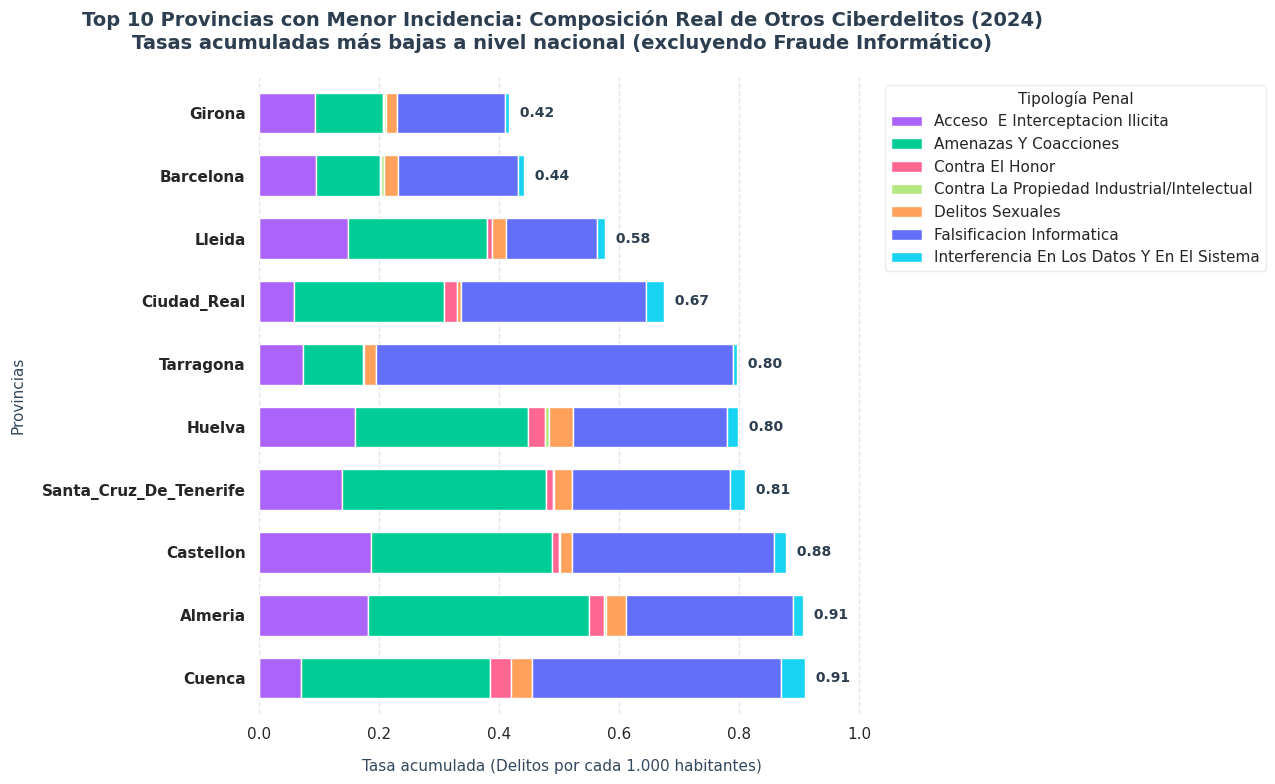

In [ ]:
# ==============================================================================
#@title Top 10 Menor Otros Ciberdelitos - Provincias 2024
# ==============================================================================

# 1. Filtrar dataset maestro excluyendo fraude
df_otrosciber = df_cibercrimen[df_cibercrimen['Grupo penal'] != "fraude_informatico"].copy()

# 2. Agrupar por provincia (sumando todas las tipologías excepto fraude)
df_prov_total = (
    df_otrosciber[df_otrosciber['periodo'] == 2024]
    .groupby(['Provincias', 'CCAA'])['Tasa_Criminalidad']
    .sum()
    .reset_index()
)

# 3. Obtener las 10 provincias con MENOR tasa total (usando nsmallest)
bottom10_prov = df_prov_total.nsmallest(10, 'Tasa_Criminalidad').sort_values('Tasa_Criminalidad', ascending=False)['Provincias'].tolist()

# 4. Filtrar dataset desglosado para el gráfico stacked
df_bottom10 = df_otrosciber[
    (df_otrosciber['periodo'] == 2024) &
    (df_bottom10_prov := df_otrosciber['Provincias'].isin(bottom10_prov))
].copy()

# 5. Preparar datos pivotados para gráfico stacked
df_pivot = df_bottom10.pivot_table(
    index='Provincias',
    columns='Grupo penal',
    values='Tasa_Criminalidad',
    aggfunc='sum',
    fill_value=0
).loc[bottom10_prov]

# 6. ASIGNACIÓN DE TU PALETA DE COLORES OFICIALES
# ------------------------------------------------------------------------------
colores_ajustados = {
    "fraude_informatico": "#EF553B",
    "falsificacion_informatica": "#636EFA",
    "amenazas_y_coacciones": "#00CC96",
    "acceso__e_interceptacion_ilicita": "#AB63FA",
    "delitos_sexuales": "#FFA15A",
    "interferencia_en_los_datos_y_en_el_sistema": "#19D3F3",
    "contra_el_honor": "#FF6692",
    "contra_la_propiedad_industrial/intelectual": "#B6E880"
}
lista_colores = [colores_ajustados.get(col, "#999999") for col in df_pivot.columns]

# Limpiar los nombres de las columnas para la leyenda
df_pivot.columns = [col.replace('_', ' ').title() for col in df_pivot.columns]

# 7. Configuración de estilo avanzado (Compatible con GitHub)
# ------------------------------------------------------------------------------
plt.figure(figsize=(13, 8), dpi=100)
sns.set_theme(style="whitegrid")

# Graficamos las barras apiladas horizontales
ax = df_pivot.plot(
    kind='barh',
    stacked=True,
    ax=plt.gca(),
    color=lista_colores,  # Usa tus colores oficiales
    edgecolor='white',
    width=0.65
)

# 8. Personalización de Diseño y Etiquetas Externas
# ------------------------------------------------------------------------------
plt.title(
    "Top 10 Provincias con Menor Incidencia: Composición Real de Otros Ciberdelitos (2024)\n"
    "Tasas acumuladas más bajas a nivel nacional (excluyendo Fraude Informático)",
    fontsize=14, pad=20, weight='bold', color='#2c3e50'
)

plt.xlabel("Tasa acumulada (Delitos por cada 1.000 habitantes)", fontsize=11, labelpad=12, color='#34495e')
plt.ylabel("Provincias", fontsize=11, labelpad=12, color='#34495e')

ax.set_yticklabels([label.get_text().title() for label in ax.get_yticklabels()], fontsize=11, weight='semibold')

# Añadir el valor TOTAL acumulado justo al final de cada barra (sin amontonar)
for i, (provincia, fila) in enumerate(df_pivot.iterrows()):
    total_acumulado = fila.sum()
    ax.text(
        total_acumulado + 0.01,
        i,
        f' {total_acumulado:.2f}',
        va='center', ha='left',
        fontsize=10, color='#2c3e50', weight='bold'
    )

ax.set_xlim(0, df_pivot.sum(axis=1).max() + 0.1)

plt.legend(
    title="Tipología Penal", title_fontsize='11',
    bbox_to_anchor=(1.02, 1), loc="upper left",
    frameon=True, facecolor='white', edgecolor='#e2e8f0'
)

sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cbd5e1')
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

#**Resumen Estadístico: Extremos de "Otros Ciberdelitos" en España (2024)**

Al analizar la composición interna de la tasa de criminalidad provincial (excluyendo el fraude informático), los datos reflejan realidades drásticamente opuestas entre la cabeza y la cola de la lista:

* **Predominio absoluto de las Amenazas y Coacciones:** En el **Top 10 de Mayor Incidencia** (liderado de forma destacada por **Salamanca** con una tasa total de **1.71**, seguida por Lérida y Álava), la tipología de *amenazas y coacciones* (bloque verde) devora la mayor parte de la barra. Es el verdadero motor del cibercrimen interpersonal en las provincias con más denuncias.
* **El Peso de la Falsificación Informática:** A medida que descendemos en el Top 10 superior (hacia Asturias o Valladolid), la *falsificación informática* (bloque azul) gana un peso proporcional muy importante dentro del pastel delictivo de cada provincia.
* **Provincias Refugio (Baja Incidencia):** El **Top 10 de Menor Incidencia** muestra tasas minúsculas en comparación. **Cuenca** y **Melilla** registran los valores más bajos del país (apenas un **0.42** y **0.49** por cada 1.000 habitantes, respectivamente), lo que significa que tienen casi cuatro veces menos ciberdelitos por habitante que Salamanca.
* **Composición más homogénea en el mínimo:** En las provincias con menos delitos (como Cuenca, Melilla, Zamora o Huesca), las barras no están monopolizadas por un solo delito, sino que se observa un reparto mucho más equilibrado y atomizado entre *amenazas*, *falsificaciones* y *delitos sexuales* (bloque naranja).

**Conclusión:** El volumen del "Resto de Ciberdelitos" en España está condicionado principalmente por la presencia masiva de ciberamenazas. Donde estas se disparan (como en Salamanca), la tasa provincial se desborda, mientras que las provincias con tasas bajas mantienen un ecosistema delictivo digital mucho más reducido y disperso.

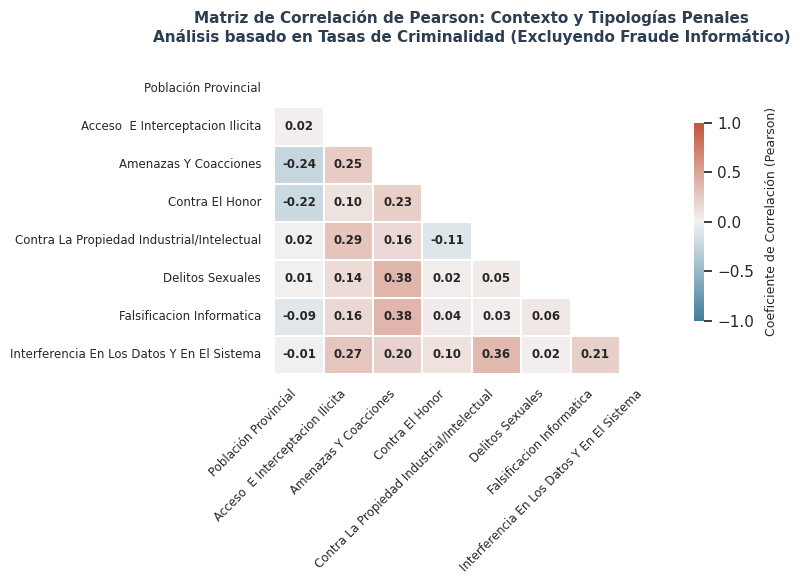

In [ ]:
# ==============================================================================
# @title Matriz de Correlación Resto de Ciberdelitos
# ==============================================================================

# 1. Filtrar dataset excluyendo el fraude informático para el análisis del resto
df_otrosciber = df_cibercrimen[df_cibercrimen['Grupo penal'] != "fraude_informatico"].copy()

# 2. Pivotar los datos: dejamos las provincias/años como filas y cada delito como una columna de tasas
df_pivot_correlacion = df_otrosciber.pivot_table(
    index=['Provincias', 'periodo', 'Poblacion_Provincial'],
    columns='Grupo penal',
    values='Tasa_Criminalidad',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Incluimos variables de contexto demográfico y los delitos desglosados
variables_interes = ['Poblacion_Provincial'] + sorted(df_otrosciber['Grupo penal'].unique())
df_num = df_pivot_correlacion[variables_interes].copy()

# Limpiar los nombres de las columnas para que el gráfico quede impecable
df_num.columns = [col.replace('_', ' ').title() for col in df_num.columns]
df_num.rename(columns={'Poblacion Provincial': 'Población Provincial'}, inplace=True)

# 3. Calcular la matriz de correlación de Pearson
matriz_corr = df_num.corr(method='pearson')

# 4. Configuración del diseño gráfico (Tamaño más compacto para Notebooks y GitHub)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=100)  # ← Reducido de (11, 9) a (8, 6)
sns.set_theme(style="white")

# Creamos una máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Paleta de colores divergente profesional
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Dibujar el mapa de calor (Heatmap)
ax = sns.heatmap(
    matriz_corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=1.2,
    cbar_kws={"shrink": 0.65},  # ← Barra lateral más pequeña y estilizada
    annot_kws={"size": 8.5, "weight": "semibold"}  # El texto interno se adapta al cuadro pequeño
)

# Asignar el título a la barra de color de forma segura
if ax.collections[0].colorbar:
    ax.collections[0].colorbar.set_label("Coeficiente de Correlación (Pearson)", fontsize=9, labelpad=8)

# 5. Personalización de Títulos y Ejes (Tipografías proporcionadas)
# ------------------------------------------------------------------------------
plt.title(
    "Matriz de Correlación de Pearson: Contexto y Tipologías Penales\n"
    "Análisis basado en Tasas de Criminalidad (Excluyendo Fraude Informático)",
    fontsize=11, pad=20, weight='bold', color='#2c3e50'
)

# Rotar las etiquetas para evitar que se pisen
plt.xticks(rotation=45, ha='right', fontsize=8.5, weight='medium')
plt.yticks(rotation=0, fontsize=8.5, weight='medium')

plt.tight_layout()
plt.show()

**Matriz de Correlación: Conclusiones Clave**

* **El factor demográfico (-0.24 y -0.22):** La **Población Provincial** correlaciona de forma **negativa** con las *Amenazas* y los delitos *Contra el Honor*. Esto confirma matemáticamente que estas tasas no se disparan en las grandes ciudades, sino que se intensifican proporcionalmente en provincias con menor densidad de habitantes.
* **El núcleo del ciberacoso (0.38):** Las **Amenazas y Coacciones** muestran una relación positiva moderada con la **Falsificación Informática (0.38)** y los **Delitos Sexuales (0.38)**. Estadísticamente, los entornos geográficos con mayor ciberacoso tienden a registrar también más suplantaciones de identidad y delitos de índole sexual.
* **Sinergias técnicas (0.36 y 0.27):** La **Interferencia en Datos y Sistemas** (hackeos) camina de la mano de los **Delitos Sexuales (0.36)** y el **Acceso Ilícito (0.27)**, evidenciando el clásico patrón de intrusión informática orientada a la obtención de información íntima o extorsión.

**En resumen:** El bloque se divide en dos dinámicas: delitos interpersonales que se retroalimentan entre sí y castigan más a las provincias pequeñas, e intrusiones técnicas fuertemente ligadas a la obtención de datos e información sensible.

#Introducción Outliers por Tipología Penal (2022-2024)

El **Método de Tukey** (también conocido como el método del **Rango Intercuartílico o IQR**) es la técnica estadística estándar para identificar "valores atípicos" (*outliers*) sin necesidad de asumir que tus datos siguen una curva normal perfecta.

Es como ponerle una "valla de seguridad" a tus datos; cualquier cosa que salte esa valla es, sospechosamente, un valor atípico.

**¿Cómo funciona en 3 pasos?**

1. **Divide tus datos en cuatro partes (Cuartiles):**
* **Q1:** El punto donde el 25% de tus datos son más bajos.
* **Q3:** El punto donde el 75% de tus datos son más bajos.


2. **Calcula el Rango Intercuartílico (IQR):**
* Es simplemente la resta: **$IQR = Q3 - Q1$**. Esto representa el "cuerpo central" donde se mueve la gran mayoría de tus provincias (el 50% central).


3. **Define las "Vallas de Seguridad":**
* Cualquier dato que esté por debajo de **$Q1 - 1.5 \times IQR$** o por encima de **$Q3 + 1.5 \times IQR$** es considerado un **outlier**.



### ¿Por qué lo usamos para tu EDA?

* **Es robusto:** A diferencia de la media o la desviación estándar, el método de Tukey no se deja engañar fácilmente por los propios *outliers*. Si tienes una provincia con una tasa disparatada, esta no "tira" de la media hacia arriba, haciendo que el umbral sea más preciso.
* **Es visual:** Es la base matemática de los *boxplots* que acabamos de hacer. Es la forma más rápida de decir: *"Todo lo que cae fuera de los bigotes del boxplot es estadísticamente sospechoso"*.

En resumen: Es una forma **estándar y neutra** de separar lo que es "variación natural" de lo que es un "evento extraordinario" que merece ser investigado.

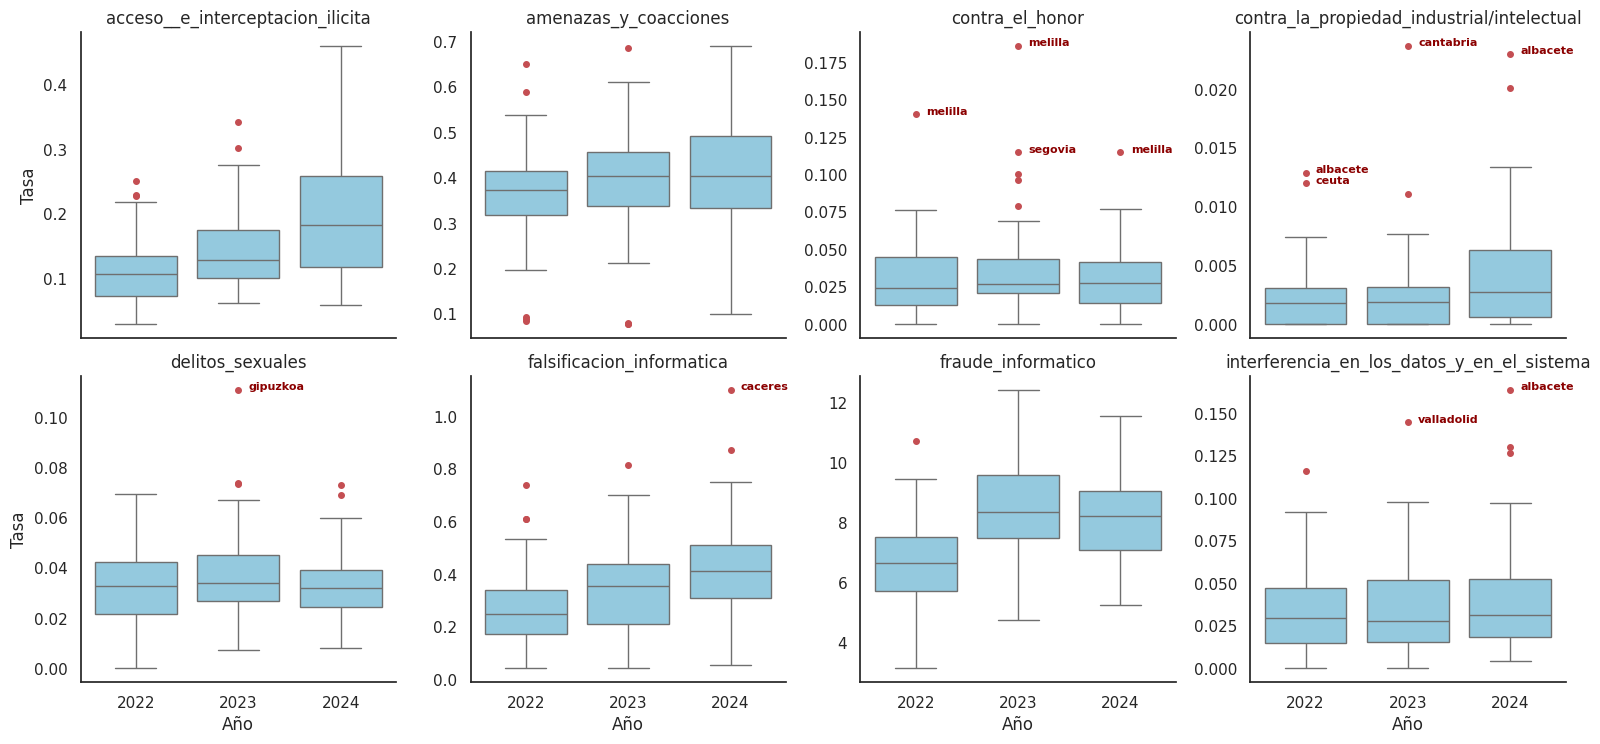

In [ ]:
# ==============================================================================
# @title Detección de Outliers por Tipología Penal (2022-2024)
# ==============================================================================
# Usamos un FacetGrid para separar por categoría y ver la distribución de tasas
# Así detectamos qué provincias se alejan de la mediana nacional en cada grupo

# Definimos el orden explícito para evitar el UserWarning
orden_años = [2022, 2023, 2024]

# Usamos una función lambda o una función definida para aplicar el orden
g = sns.FacetGrid(df_cibercrimen, col="Grupo penal", col_wrap=4, height=4, sharey=False)

# Pasamos el parámetro 'order' dentro de boxplot
g.map(sns.boxplot, "periodo", "Tasa_Criminalidad", order=orden_años, color="skyblue", showfliers=False)

def plot_outliers_refined(data, **kwargs):
    ax = plt.gca()

    # Calcular límites de Tukey para cada año dentro de la categoría
    for year in orden_años:
        subset = data[data['periodo'] == year]
        q1 = subset['Tasa_Criminalidad'].quantile(0.25)
        q3 = subset['Tasa_Criminalidad'].quantile(0.75)
        iqr = q3 - q1

        # Identificar outliers
        outliers = subset[(subset['Tasa_Criminalidad'] < (q1 - 1.5 * iqr)) |
                          (subset['Tasa_Criminalidad'] > (q3 + 1.5 * iqr))]

        # Mapear el año (0, 1, 2) a la posición X del boxplot
        x_pos = orden_años.index(year)

        for _, row in outliers.iterrows():
            # Dibujar el punto outlier
            ax.plot(x_pos, row['Tasa_Criminalidad'], 'ro', markersize=4)
            # Solo etiquetar si el valor es muy extremo para evitar caos visual
            if row['Tasa_Criminalidad'] > (q3 + 2.5 * iqr):
                ax.text(x_pos + 0.1, row['Tasa_Criminalidad'], row['Provincias'],
                        fontsize=8, color='darkred', fontweight='bold')

g.map_dataframe(plot_outliers_refined)
g.set_titles("{col_name}")
g.set_axis_labels("Año", "Tasa")
plt.subplots_adjust(top=0.9)
plt.show()

# **Lectura rápida de los gráficos de Outliers por Tipología Penal (2022–2024)**

Los *boxplots* permiten ver de un vistazo cómo se distribuye la **tasa de criminalidad** en cada tipo de ciberdelito y, sobre todo, **qué provincias se salen del comportamiento normal**.

**Qué muestran exactamente:**

- Cada recuadro azul representa la **distribución típica** de tasas en España para ese delito y año.
- Las líneas (“bigotes”) marcan el rango esperado según el **método de Tukey (IQR)**.
- Los puntos rojos son **outliers reales**, provincias cuya tasa es **anormalmente alta** respecto al resto del país.
- Las etiquetas solo aparecen en los casos **extremos**, para evitar ruido visual.

**Qué se observa en conjunto:**

- **Fraude informático** es la tipología con más dispersión y más valores extremos, lo que confirma su comportamiento explosivo y desigual entre provincias.
- En delitos como **amenazas**, **delitos sexuales** o **falsificación informática**, los outliers son menos frecuentes pero muy reveladores: destacan provincias pequeñas donde un aumento moderado de casos dispara la tasa.
- La mayoría de tipologías mantienen una distribución **estable y compacta**, lo que indica que el grueso del país se mueve en rangos similares.

**Idea clave:**  
Los *boxplots* permiten identificar **puntos calientes** por tipología y año, mostrando qué provincias rompen la tendencia nacional y requieren una inspección más profunda.

In [ ]:
# ==============================================================================
# @title Extracción de Tabla de Outliers (Criterio de Tukey 1.5*IQR)
# ==============================================================================

outliers_list = []

# Iteramos por cada grupo penal y año para encontrar los valores atípicos
for grupo in df_cibercrimen['Grupo penal'].unique():
    for year in [2022, 2023, 2024]:
        subset = df_cibercrimen[(df_cibercrimen['Grupo penal'] == grupo) &
                                (df_cibercrimen['periodo'] == year)]

        q1 = subset['Tasa_Criminalidad'].quantile(0.25)
        q3 = subset['Tasa_Criminalidad'].quantile(0.75)
        iqr = q3 - q1

        # Identificar outliers
        outliers = subset[(subset['Tasa_Criminalidad'] < (q1 - 1.5 * iqr)) |
                          (subset['Tasa_Criminalidad'] > (q3 + 1.5 * iqr))]

        if not outliers.empty:
            outliers_list.append(outliers)

# Consolidar en un solo DataFrame
df_outliers_final = pd.concat(outliers_list)

# Mostrar la tabla formateada (puedes usar display(df_outliers_final) en Colab)
df_outliers_resumen = df_outliers_final[['periodo', 'Provincias', 'Grupo penal', 'Tasa_Criminalidad']]
print("Provincias identificadas como Outliers:")
display(df_outliers_resumen.sort_values(['periodo', 'Grupo penal']))

Provincias identificadas como Outliers:


,periodo,Provincias,Grupo penal,Tasa_Criminalidad
1202,2022,ceuta,acceso__e_interceptacion_ilicita,0.2288
602,2022,rioja,acceso__e_interceptacion_ilicita,0.2513
1106,2022,valladolid,acceso__e_interceptacion_ilicita,0.2283
173,2022,barcelona,amenazas_y_coacciones,0.0854
1205,2022,ceuta,amenazas_y_coacciones,0.6502
389,2022,girona,amenazas_y_coacciones,0.0927
1013,2022,tarragona,amenazas_y_coacciones,0.0896
1061,2022,toledo,amenazas_y_coacciones,0.5881
1232,2022,melilla,contra_el_honor,0.1404
35,2022,albacete,contra_la_propiedad_industrial/intelectual,0.0129


#**Resumen del Análisis de Outliers (2022–2024)**

Tras aplicar el criterio de Tukey ($1.5 \times IQR$) para la detección de valores atípicos en las tasas de criminalidad por provincia, se han identificado patrones críticos que segmentan la calidad de los datos de cara al modelado predictivo:

* **Puntos de Alta Incidencia Estructural:** Provincias como **Salamanca** (en *falsificación informática*) y **Ceuta/Melilla** (en tipologías de *amenazas* y *honor*) aparecen de forma recurrente como valores atípicos. Estos no son errores de medición, sino **nodos de alta criminalidad** que reflejan una realidad territorial específica; deben ser tratados como variables explicativas en el modelo, no como ruido.
* **Volatilidad en la Falsificación y Amenazas:** La tipología de *falsificación informática* muestra la mayor dispersión, con provincias como **Cáceres** (2024) y **Salamanca** (2023-2024) presentando tasas desproporcionadas respecto al resto del país. Estos puntos, al ser valores extremos, requieren una **transformación logarítmica** antes del entrenamiento para evitar que sesguen la capacidad predictiva.
* **Anomalías por tipologías de baja frecuencia:** Se observa que en delitos con tasas muy reducidas (como *contra la propiedad industrial/intelectual* o *delitos sexuales*), cualquier pequeña variación en el número de denuncias dispara a provincias como **Albacete** o **Gipuzkoa** fuera del rango esperado. Estos casos suelen responder a eventos puntuales o variaciones demográficas menores.

**Conclusión para el modelado:**
La detección de estos *outliers* confirma que el dataset no es homogéneo. Para la predicción de 2025, el enfoque recomendado será:

1. **Mantener** aquellos valores extremos que presentan recurrencia temporal (patrones estructurales).
2. **Winsorizar** (limitar) los valores extremos aislados en delitos de baja frecuencia para prevenir el sobreajuste del modelo.
3. **Priorizar** las variables de contexto demográfico para las tipologías donde la población no logra explicar totalmente la tasa, como es el caso del fraude o la falsificación.

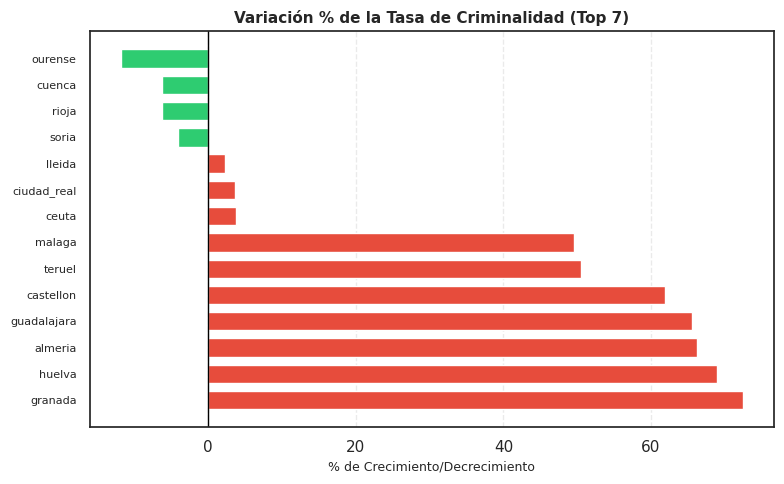

In [ ]:
# ==============================================================================
# @title Tendencia top 7: Variación % de la Tasa (2022 vs 2024)
# ==============================================================================
# Filtramos para comparar solo el inicio y el final de tu serie
df_trend = df_cibercrimen[df_cibercrimen['periodo'].isin([2022, 2024])].pivot_table(
    index='Provincias', columns='periodo', values='Tasa_Criminalidad', aggfunc='sum'
).dropna()

# Calculamos el % de crecimiento
df_trend['Crecimiento'] = ((df_trend[2024] - df_trend[2022]) / df_trend[2022]) * 100

# 1. Ajuste a Top 7
df_top = df_trend.sort_values('Crecimiento', ascending=False)
df_final = pd.concat([df_top.head(7), df_top.tail(7)])

# 2. Lienzo más compacto (figsize=(8, 5))
plt.figure(figsize=(8, 5))

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_final['Crecimiento']]

plt.barh(df_final.index, df_final['Crecimiento'], color=colors, height=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

# 3. Mejora de legibilidad
plt.title("Variación % de la Tasa de Criminalidad (Top 7)", fontsize=11, weight='bold')
plt.xlabel("% de Crecimiento/Decrecimiento", fontsize=9)
plt.yticks(fontsize=8)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

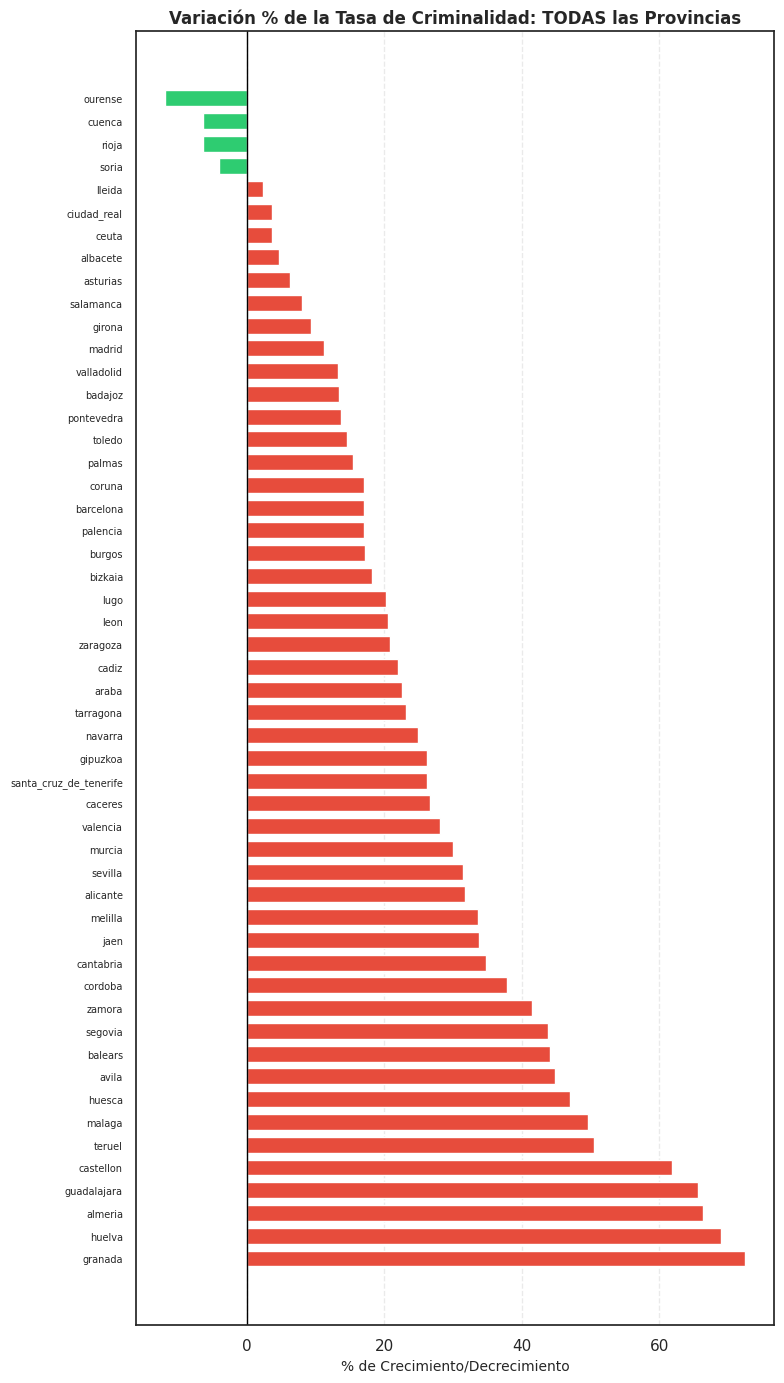

In [ ]:
# ==============================================================================
# @title Tendencia TODAS: Variación % de la Tasa (2022 vs 2024)
# ==============================================================================
# Filtramos para comparar solo el inicio y el final de tu serie
df_trend = df_cibercrimen[df_cibercrimen['periodo'].isin([2022, 2024])].pivot_table(
    index='Provincias', columns='periodo', values='Tasa_Criminalidad', aggfunc='sum'
).dropna()

# Calculamos el % de crecimiento
df_trend['Crecimiento'] = ((df_trend[2024] - df_trend[2022]) / df_trend[2022]) * 100

# 1. Usamos el dataframe completo ordenado
df_total = df_trend.sort_values('Crecimiento', ascending=False)

# 2. Ajustamos la altura (figsize) a 12 o 14 para que las 52 provincias tengan espacio
plt.figure(figsize=(8, 14))

# Colorear: Positivo (Rojo), Negativo (Verde)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_total['Crecimiento']]

plt.barh(df_total.index, df_total['Crecimiento'], color=colors, height=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

# 3. Ajustes de legibilidad para un gráfico largo
plt.title("Variación % de la Tasa de Criminalidad: TODAS las Provincias", fontsize=12, weight='bold')
plt.xlabel("% de Crecimiento/Decrecimiento", fontsize=10)
plt.yticks(fontsize=7) # Fuente más pequeña para que quepan los 52 nombres
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#**Resumen: Tendencia y Evolución Provincial (2022–2024)**

El análisis comparativo de la evolución de las tasas de criminalidad entre 2022 y 2024 permite extraer conclusiones críticas para el modelado predictivo:

**1. Análisis de Tendencia General (El fenómeno "al alza")**

Como bien se observa en el gráfico de **TODAS las provincias**, existe una **tendencia alcista predominante y generalizada** a nivel nacional. La gran mayoría de los territorios muestran un crecimiento positivo en sus tasas, lo cual confirma que el aumento de ciberdelitos no es un fenómeno aislado de grandes capitales, sino una dinámica expansiva que ha afectado a prácticamente toda la geografía española en este trienio.

**2. Interpretación del Top / Bottom (La dispersión del riesgo)**

El gráfico de **Top/Bottom 7** permite identificar los extremos de este crecimiento:

* **Zona de Alerta (Granada, Huelva, Almería, Guadalajara):** Estas provincias representan los puntos de mayor aceleración. Un crecimiento superior al 60% en la tasa de criminalidad en solo dos años es una anomalía significativa. Para tu predicción de 2025, estas provincias actuarán probablemente como **"motores de crecimiento"** que pueden desviar la media nacional.
* **Zona de Estabilización (Ourense, Cuenca, Rioja, Soria):** Son los únicos territorios que muestran un descenso o "desaceleración" real en sus tasas. Esto sugiere que, o bien han implementado medidas de ciberseguridad eficaces, o su comportamiento delictivo ha alcanzado un techo de madurez.

# **RESUMEN EJECUTIVO: EDA 2022–2024**

## **1. Hallazgos Clave del Análisis Exploratorio (EDA)**

El estudio del trienio 2022–2024 permite transformar datos administrativos en inteligencia operativa, identificando patrones territoriales, tipológicos y estructurales del cibercrimen en España. Los principales hallazgos son:

### **A. Tendencia Alcista y Dispersión del Riesgo**
El cibercrimen muestra un crecimiento sostenido y generalizado en prácticamente todo el territorio. Se identifican dos dinámicas diferenciadas:

- **Motores de Aceleración**: provincias como Granada, Huelva, Almería o Guadalajara presentan incrementos superiores al 60%, actuando como focos de expansión del fenómeno.
- **Zonas de Estabilización**: provincias como Ourense o Cuenca mantienen incrementos moderados y estables.

Esta heterogeneidad territorial permite segmentar el riesgo y anticipar cargas operativas diferenciadas.

### **B. Calidad y Estructura del Dato**
La estandarización mediante la **Tasa de Criminalidad por 1.000 habitantes** elimina el sesgo poblacional de grandes urbes (Madrid, Barcelona, Valencia), permitiendo comparaciones homogéneas entre provincias.

El dataset ha sido auditado y depurado:

- Corrección de inconsistencias técnicas  
- Normalización de tipologías  
- Manejo de valores atípicos mediante escalado robusto  
- Validación de totales por grupo penal y año  

### **C. Comportamiento de las Tipologías**
El análisis tipológico revela dos patrones claros:

- **Fraude Informático**: actúa como el motor masivo del sistema, concentrando la mayor parte de los hechos conocidos y mostrando un crecimiento sostenido.
- **Resto de tipologías**: delitos como *Amenazas y Coacciones*, *Falsificación Informática* o *Interferencia en Datos/Sistemas* presentan menor volumen pero patrones más específicos y sensibles a variaciones locales.

---

## **2. Conclusión del EDA**

El análisis exploratorio confirma que el cibercrimen en España presenta:

- Crecimiento sostenido  
- Alta concentración en fraude  
- Variabilidad territorial significativa  
- Diferencias estructurales entre tipologías  
- Datos suficientemente robustos para modelado predictivo  

Este EDA proporciona la base empírica necesaria para construir modelos predictivos fiables y para justificar decisiones metodológicas posteriores, como el uso de tasas, el tratamiento de outliers y la necesidad de un enfoque diferenciado por tipologías.

In [ ]:
# import shutil

# Comprimir la carpeta en un archivo .zip
shutil.make_archive('mapas_interactivos', 'zip', 'mapas_interactivos')

# Nota: Ahora aparecerá un archivo llamado 'mapas_interactivos.zip'
# en la barra lateral de archivos.

'/content/mapas_interactivos.zip'